In [1]:
import os, copy
import numpy as np
import jax
import jax.numpy as jnp
from jax import vmap
import matplotlib.pyplot as plt
import pandas as pd
import interpax
from scipy.interpolate import interp1d

from jax_cosmo import Cosmology
import jax_cosmo.background as bkgrd
from jax_cosmo.background import radial_comoving_distance

from godmax.get_Cls  import get_Cl
from godmax.get_covs import get_cov
from godmax.base_class import get_vmapped_func_warg
from godmax.base_class import base_class
from godmax.get_radial_profiles import Profiles
from godmax.get_Pkzs import get_Pkz

from tSZxEuclid.godmax.config.loader import merge_params
from tSZxEuclid.godmax.sampling.ell  import setup_ell_arrays

import diag_utils

/home/vtinnane/micromamba/envs/tSZxEuclid-godmax/lib/python3.11/site-packages/jax_cosmo/__init__.py:2: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound


In [2]:
from pathlib import Path

# ── Anchor: directory containing this notebook ───────────────────────────────
HERE = Path().resolve()          
DEVELOP = HERE.parents[2]        

# ── Parameter files (diagnostics/params/) ────────────────────────────────────
PARAM_DIR = HERE / 'params'
sim_params_dict, halo_params_dict, analysis_dict, other_params_dict = merge_params(
    str(PARAM_DIR / 'params_default.yaml'),
    str(PARAM_DIR / 'params.yaml'),
)

halo_params_dict['lowpass_Pmm1h_lowk'] = True
halo_params_dict['kthresh_lowpass_Pmm1h_lowk'] = 0.01  # k in h/Mpc below which 1h is suppressed                          
analysis_dict['is_cmb_lensing'] = True          

# ── Cosmology (jax_cosmo) ────────────────────────────────────────────────────
cosmo_params = sim_params_dict['cosmo']
cosmo_jax = Cosmology(
    Omega_c  = cosmo_params['Om0'] - cosmo_params['Ob0'],
    Omega_b  = cosmo_params['Ob0'],
    h        = cosmo_params['H0'] / 100.,
    sigma8   = cosmo_params['sigma8'],
    n_s      = cosmo_params['ns'],
    Omega_k  = 0.,
    w0       = cosmo_params.get('w0', -1.0),
    wa       = 0.,
)

# ── ell array (mutates analysis_dict and halo_params_dict in place) ──────────
setup_ell_arrays(analysis_dict, halo_params_dict, lmin=80.0, lmax=8000.0, dl_log=0.23025851)
print(f"nell = {len(analysis_dict['l_array_survey'])}, "
      f"ell range [{float(analysis_dict['l_array_survey'][0]):.1f}, "
      f"{float(analysis_dict['l_array_survey'][-1]):.1f}]")

# ── Galaxy n(z) paths ────────────────────────────────────────────────────────
DNDZ_DIR = DEVELOP / 'tSZxEuclid' / 'Data' / 'dndz'

def to_comoving_nz(z_array, nz_array, cosmo):
    """Convert non-normalised n(z) [#gal/z] to comoving n(z) [(Mpc/h)^-3]."""
    a = 1.0 / (1.0 + z_array)
    chi = radial_comoving_distance(cosmo, a)
    dchi_dz = (2.998e5) / bkgrd.H(cosmo, a)   # c [km/s] / H(a) [km/s/(Mpc/h)]
    dV_dzdOmega = chi**2 * dchi_dz
    return nz_array / dV_dzdOmega

dndz_gal = np.loadtxt(DNDZ_DIR / 'nz_euclid_forecast_bin-all.txt')
z_gal  = dndz_gal[:, 0]
nz_gal = dndz_gal[:, 1]
nz_gal_comoving = to_comoving_nz(z_gal, nz_gal, cosmo_jax)
analysis_dict['nbar_gal_comoving_zarray'] = z_gal
analysis_dict['nbar_gal_comoving_val']    = nz_gal_comoving

# ── Lens N(z) bins ───────────────────────────────────────────────────────────
nbins_lens   = 5
nz_lens      = {}
nz_info_dict = {'nbins_lens': nbins_lens}

for nbin in range(nbins_lens):
    d = np.loadtxt(DNDZ_DIR / f'nz_norm_euclid_forecast_bin-{nbin+1}.txt')
    nz_lens[nbin]              = d[:, 1]
    nz_info_dict[f'nz{nbin}'] = nz_lens[nbin]
z_lens = d[:, 0]
nz_info_dict['z_array_lens'] = z_lens
analysis_dict['nz_lens_info_dict'] = nz_info_dict

# ── Source N(z) bins (same as lens for mock) ─────────────────────────────────
nbins_source = 5
nz_source  = {}
nz_info_src = {'nbins': nbins_source}

for nbin in range(nbins_source):
    d = np.loadtxt(DNDZ_DIR / f'nz_norm_euclid_forecast_bin-{nbin+1}.txt')
    nz_source[nbin]             = d[:, 1]
    nz_info_src[f'nz{nbin}']  = nz_source[nbin]
z_source = d[:, 0]
nz_info_src['z_array_source'] = z_source
analysis_dict['nz_source_info_dict'] = nz_info_src

# ── Per-bin nbar [gal/arcmin²] ───────────────────────────────────────────────
deg2_to_arcmin2 = 3600.0
nz_gal_interp   = interp1d(z_gal, nz_gal, bounds_error=False, fill_value=0.0)
nz_gal_on_zlens = nz_gal_interp(z_lens)

pz_bins = np.vstack([nz_lens[jb] for jb in range(nbins_lens)])   # (nbins, Nz)
pz_sum  = np.sum(pz_bins, axis=0)
nbar_lens_bins = np.zeros(nbins_lens)
for jb in range(nbins_lens):
    frac_j = np.zeros_like(z_lens)
    valid  = pz_sum > 0
    frac_j[valid] = pz_bins[jb, valid] / pz_sum[valid]
    nbar_lens_bins[jb] = np.trapezoid(nz_gal_on_zlens * frac_j, z_lens) / deg2_to_arcmin2
analysis_dict['nbar_lens_bins'] = nbar_lens_bins

# ── SO LAT noise ─────────────────────────────────────────────────────────────
SO_NOISE = DEVELOP / 'tSZxEuclid' / 'Data' / 'SO_LAT_Nell_T_atmv1_baseline_fsky0p4_ILC_tSZ.txt'
analysis_dict['yy_noise_ell_fname'] = str(SO_NOISE)

# ── Output directory for figures ─────────────────────────────────────────────
FIGDIR = HERE / 'plots'
FIGDIR.mkdir(exist_ok=True)

print('nbar_lens_bins [gal/arcmin²]:', nbar_lens_bins)
print(f"Halo mass range: [{halo_params_dict['lg10_Mmin']}, {halo_params_dict['lg10_Mmax']}], nM={halo_params_dict['nM']}")
print(f"z grid: [{halo_params_dict['zmin']}, {halo_params_dict['zmax']}], nz={halo_params_dict['nz']}")
print(f"PARAM_DIR : {PARAM_DIR}")
print(f"DNDZ_DIR  : {DNDZ_DIR}")
print(f"FIGDIR    : {FIGDIR}")


ERROR:2026-04-15 14:04:50,783:jax._src.xla_bridge:475: Jax plugin configuration error: Exception when calling jax_plugins.xla_cuda12.initialize()
Traceback (most recent call last):
  File "/home/vtinnane/micromamba/envs/tSZxEuclid-godmax/lib/python3.11/site-packages/jax/_src/xla_bridge.py", line 473, in discover_pjrt_plugins
    plugin_module.initialize()
  File "/home/vtinnane/micromamba/envs/tSZxEuclid-godmax/lib/python3.11/site-packages/jax_plugins/xla_cuda12/__init__.py", line 328, in initialize
    _check_cuda_versions(raise_on_first_error=True)
  File "/home/vtinnane/micromamba/envs/tSZxEuclid-godmax/lib/python3.11/site-packages/jax_plugins/xla_cuda12/__init__.py", line 285, in _check_cuda_versions
    local_device_count = cuda_versions.cuda_device_count()
                         ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
RuntimeError: jaxlib/cuda/versions_helpers.cc:113: operation cuInit(0) failed: Unknown CUDA error 303; cuGetErrorName failed. This probably means that JAX was unable to

nell = 19, ell range [90.4, 5701.1]
nbar_lens_bins [gal/arcmin²]: [0.91251697 0.8918078  0.8918939  0.93620033 1.58377251]
Halo mass range: [11.5, 15.5], nM=24
z grid: [0.01, 1.6], nz=22
PARAM_DIR : /home/vtinnane/Documents/Codes/develop/GODMAX/notebooks/diagnostics/params
DNDZ_DIR  : /home/vtinnane/Documents/Codes/develop/tSZxEuclid/Data/dndz
FIGDIR    : /home/vtinnane/Documents/Codes/develop/GODMAX/notebooks/diagnostics/plots


In [3]:
base_test = base_class(sim_params_dict, halo_params_dict, analysis_dict, other_params_dict)
profiles_test = Profiles(sim_params_dict, halo_params_dict, analysis_dict, other_params_dict, base_class_obj=base_test)
Pkz_test = get_Pkz(sim_params_dict, halo_params_dict, analysis_dict, other_params_dict, Profiles_obj=profiles_test)
Cls_test = get_Cl(sim_params_dict, halo_params_dict, analysis_dict, other_params_dict, Pkz_obj=Pkz_test)
cov_test = get_cov(sim_params_dict, halo_params_dict, analysis_dict, other_params_dict, Cls_test)

z_th = np.array(Cls_test.z_array)
nz = len(z_th)
z_sel = np.unique([0, nz//4, nz//2, 3*nz//4, nz-1])
ell_th = np.array(analysis_dict['l_array_survey'])

Loaded yy noise from file; Cl_y_y_tot_mat = theory + noise


In [4]:
probe_sets = [                                                                                      
    ['gy'], ['gg'], ['ky'], ['kk'], ['gk'], ['yy'],
    ['gy', 'gg'], ['ky', 'gy'], ['ky', 'kk'], ['yy', 'gk'],
    ['ky', 'kk', 'gy', 'gg'],                                                                       
    ['ky', 'kk', 'gy', 'gg', 'gk', 'yy'],
]

Cl_dict  = cov_test.Cl_result_dict
cov_dict = cov_test.covtot_dict

datavec = []
cov = []
for probes in probe_sets:
    dv, entries, nell = diag_utils.build_data_vector(Cl_dict, probes)
    cm, entries, count_per_probe, nell = diag_utils.build_cov_matrix(cov_dict, Cl_dict, probes)
    datavec.append((dv, entries, nell))
    cov.append((cm, entries, count_per_probe, nell))

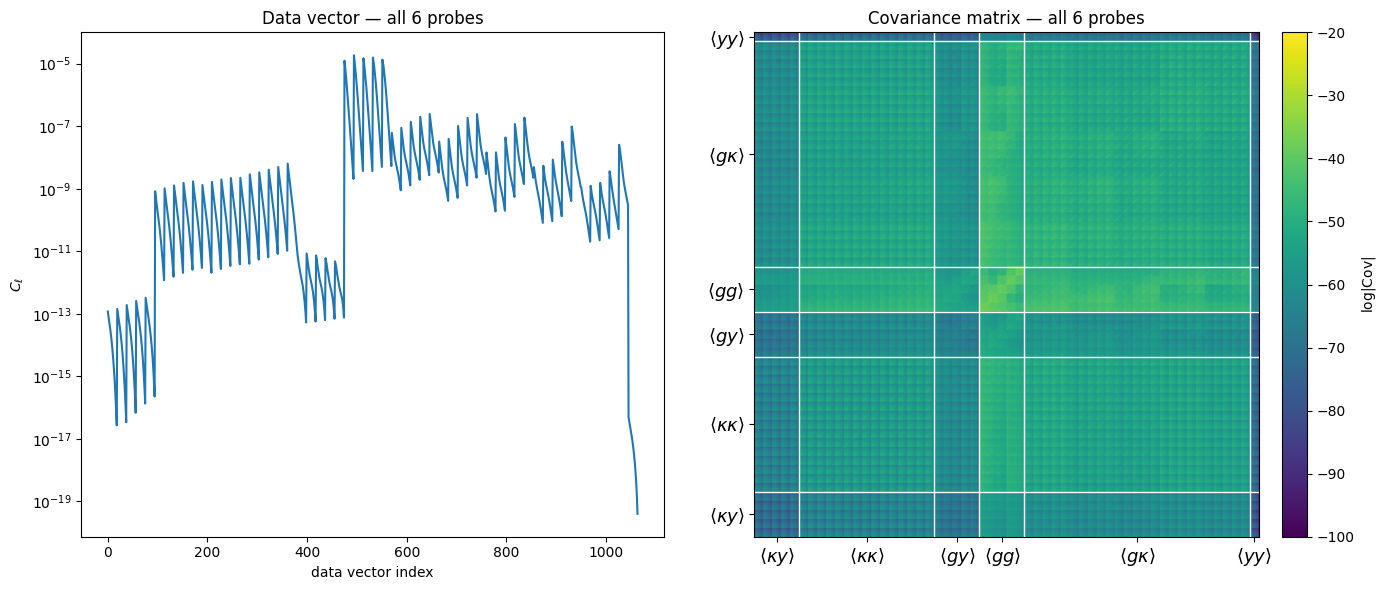

In [5]:
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.plot(datavec[11][0])
plt.yscale('log')
plt.xlabel('data vector index')
plt.ylabel(r'$C_\ell$')
plt.title('Data vector — all 6 probes')

ax = plt.subplot(1, 2, 2)
diag_utils.plot_cov_matrix(cov[11][0], cov[11][2], probe_sets[11], cov[11][3], ax=ax)
ax.set_title('Covariance matrix — all 6 probes')

plt.tight_layout()
plt.show()

In [13]:
# Regularisation functions
# Four families:
#   1. Eigenvalue clipping / shifting    (clip_neg0, diag_shift, diag_shift_x11)
#   2. Isotropic noise floor             (noise_floor_01p, noise_floor_1p)
#   3. Condition-number clamp            (cond_clamp; Chen et al. 2010)
#   4. Mode truncation                   (trunc_modes; Fortuna et al. 2021)
#   5. Entry-wise hard thresholding      (hard_threshold; Bickel & Levina 2008)

def _cond_floor(eigvals, kappa_max):
    return max(float(eigvals.max()), 0.0) / float(kappa_max)


def regularise(C, method, **kw):
    C = np.array(C, dtype=float)
    C = (C + C.T) / 2.0

    if method == 'original':
        return C

    if method == 'hard_threshold':
        d      = np.sqrt(np.maximum(np.diag(C), 0.0))
        d_safe = np.where(d > 0, d, 1.0)
        corr   = C / np.outer(d_safe, d_safe)
        frac   = kw.get('frac', 0.1)
        eye    = np.eye(len(C), dtype=bool)
        off    = np.abs(corr[~eye])
        s      = frac * off.max() if len(off) > 0 else 0.0
        corr_t = corr.copy()
        corr_t[(np.abs(corr) < s) & ~eye] = 0.0
        return corr_t * np.outer(d_safe, d_safe)

    eigvals, eigvecs = np.linalg.eigh(C)
    eps_mach = np.finfo(float).eps   # ~2.2e-16

    if method == 'clip_neg0':
        # Floor at eps_machine * lambda_max rather than exactly 0.
        # Flooring at 0 leaves reconstruction roundoff ~eps_mach*lambda_max
        # that shows up as tiny negative eigenvalues (~1e-29) when re-diagonalised,
        # giving cond=inf and chi2/ndof -> inf.  eps_mach floor costs nothing.
        lam = np.maximum(eigvals, eps_mach * eigvals.max())

    elif method == 'diag_shift':
        shift = max(-eigvals.min(), 0.0)
        lam   = eigvals + shift

    elif method == 'diag_shift_x11':
        eps   = 1e-10 * np.abs(eigvals).max()
        shift = max(-eigvals.min(), 0.0)
        lam   = eigvals + 1.1 * shift + eps

    elif method == 'noise_floor_01p':
        lam = eigvals + 0.001 * np.mean(np.diag(C))

    elif method == 'noise_floor_1p':
        lam = eigvals + 0.01 * np.mean(np.diag(C))

    elif method == 'cond_clamp':
        kappa_max = float(kw.get('kappa_max', 1e6))
        tau = _cond_floor(eigvals, kappa_max)
        lam = np.maximum(eigvals, tau)

    elif method == 'trunc_modes':
        n_trunc = int(kw.get('n_trunc', 1))
        lam     = eigvals.copy()
        idx_asc = np.argsort(lam)
        floor   = max(float(lam[idx_asc[n_trunc]]), 0.0) if n_trunc < len(lam) else 0.0
        lam[idx_asc[:n_trunc]] = floor

    elif method == 'lam_abs':
        # Reflect negative eigenvalues: lambda -> |lambda|
        # Bickel & Levina 2008 — congruence transform D M D with D=diag(sign(lam))
        lam = np.abs(eigvals)

    elif method == 'eig_perturb':
        # Perturb eigenvalues: lambda_new = |lambda| * (1 + delta)
        # delta ~ N(0, x/100), |delta| < 1  -> lambda_new always > 0
        # Ref: Eq.(16) of paper; x controls perturbation magnitude (default 5%)
        x   = float(kw.get('x', 5.0))
        rng = np.random.default_rng(int(kw.get('seed', 42)))
        delta = rng.normal(0.0, x / 100.0, size=len(eigvals))
        delta = np.clip(delta, -0.99, 0.99)   # |delta| < 1 strictly
        lam   = np.abs(eigvals) * (1.0 + delta)
        # floor at eps * lambda_max to avoid exact zeros
        lam   = np.maximum(lam, eps_mach * np.abs(eigvals).max())

    else:
        raise ValueError(f'Unknown regularisation method: {method!r}')

    return eigvecs @ np.diag(lam) @ eigvecs.T


METHODS = {
    'original':        dict(method='original'),
    'clip_neg0':       dict(method='clip_neg0'),
    'diag_shift':      dict(method='diag_shift'),
    'diag_shift_x11':  dict(method='diag_shift_x11'),
    'lam_abs':         dict(method='lam_abs'),
    'eig_perturb_5':   dict(method='eig_perturb', x=5.0,  seed=42),
    'eig_perturb_10':  dict(method='eig_perturb', x=10.0, seed=42),
    'noise_floor_01p': dict(method='noise_floor_01p'),
    'noise_floor_1p':  dict(method='noise_floor_1p'),
    'cond_1e3':        dict(method='cond_clamp', kappa_max=1e3),
    'cond_1e4':        dict(method='cond_clamp', kappa_max=1e4),
    'cond_1e6':        dict(method='cond_clamp', kappa_max=1e6),
    'trunc_1':         dict(method='trunc_modes', n_trunc=1),
    'trunc_5':         dict(method='trunc_modes', n_trunc=5),
    'hard_s01':        dict(method='hard_threshold', frac=0.01),
    'hard_s05':        dict(method='hard_threshold', frac=0.05),
}

METHOD_LABELS = {
    'original':        'original',
    'clip_neg0':       r'clip $\lambda<0$',
    'diag_shift':      r'diag shift',
    'diag_shift_x11':  r'diag shift $\times1.1$',
    'lam_abs':         r'|\lambda| reflection',
    'eig_perturb_5':   r'eig perturb $x=5\%$',
    'eig_perturb_10':  r'eig perturb $x=10\%$',
    'noise_floor_01p': r'noise floor $10^{-3}$',
    'noise_floor_1p':  r'noise floor $10^{-2}$',
    'cond_1e3':        r'CNR $\kappa_{\max}=10^3$',
    'cond_1e4':        r'CNR $\kappa_{\max}=10^4$',
    'cond_1e6':        r'CNR $\kappa_{\max}=10^6$',
    'trunc_1':         r'trunc $N=1$',
    'trunc_5':         r'trunc $N=5$',
    'hard_s01':        r'hard thresh $f=0.01$',
    'hard_s05':        r'hard thresh $f=0.05$',
}

METHOD_COLORS = {
    'original':        '#000000',
    'clip_neg0':       '#1f77b4',
    'diag_shift':      '#aec7e8',
    'diag_shift_x11':  '#2171b5',
    'lam_abs':         '#9ecae1',
    'eig_perturb_5':   '#fd8d3c',
    'eig_perturb_10':  '#d94801',
    'noise_floor_01p': '#74c476',
    'noise_floor_1p':  '#238b45',
    'cond_1e3':        '#fdae6b',
    'cond_1e4':        '#e6550d',
    'cond_1e6':        '#a63603',
    'trunc_1':         '#d62728',
    'trunc_5':         '#9467bd',
    'hard_s01':        '#e377c2',
    'hard_s05':        '#7f7f7f',
}

# safety: auto-fill any key in METHODS that was forgotten in the label/colour dicts
for _k in METHODS:
    METHOD_LABELS.setdefault(_k, _k)
    METHOD_COLORS.setdefault(_k, '#888888')

print(f'Registered {len(METHODS)} regularisation methods.')
missing = set(METHODS) - set(METHOD_LABELS)
if missing:
    print(f'  [warn] auto-filled missing labels: {missing}')
else:
    print('  all keys consistent across METHODS / METHOD_LABELS / METHOD_COLORS')


Registered 16 regularisation methods.
  all keys consistent across METHODS / METHOD_LABELS / METHOD_COLORS


In [14]:
# ──────────────────────────────────────────────────────────────────────────────
# Apply all regularisation methods and compute metrics
# ──────────────────────────────────────────────────────────────────────────────
# Target: full 6-probe covariance (probe_sets[11])
# ──────────────────────────────────────────────────────────────────────────────

C_orig = cov[11][0].copy()
dv     = datavec[11][0].copy()
ndof   = len(dv)

sign0, logdet0 = np.linalg.slogdet(C_orig)

C_reg_all = {}
metrics   = {}

for name, kw in METHODS.items():
    C_reg = regularise(C_orig, **kw)
    C_reg_all[name] = C_reg

    eigvals         = np.linalg.eigvalsh(C_reg)
    lam_min         = float(eigvals.min())
    lam_max         = float(eigvals.max())
    is_psd          = bool(lam_min >= 0)
    cond            = lam_max / lam_min if lam_min > 0 else np.inf

    frob = float(np.linalg.norm(C_reg - C_orig, 'fro'))
    spec = float(np.linalg.norm(C_reg - C_orig, 2))

    sign, logdet = np.linalg.slogdet(C_reg)
    delta_logdet = float(logdet - logdet0) if (sign > 0 and sign0 > 0) else np.nan

    # χ²/ndof  — use pseudoinverse so singular methods (clip_neg0, trunc) don't crash
    try:
        C_inv = np.linalg.pinv(C_reg, rcond=1e-15)
        chi2  = float(dv @ C_inv @ dv) / ndof
    except Exception:
        chi2 = np.nan

    metrics[name] = dict(
        lam_min      = lam_min,
        lam_max      = lam_max,
        is_psd       = is_psd,
        cond         = cond,
        frob         = frob,
        spec         = spec,
        delta_logdet = delta_logdet,
        chi2_ndof    = chi2,
    )

df_metrics = pd.DataFrame(metrics).T
df_metrics.index.name = 'method'
display(df_metrics[['lam_min', 'cond', 'frob', 'spec', 'delta_logdet', 'chi2_ndof', 'is_psd']]
        .style.format({
            'lam_min': '{:.3e}', 'lam_max': '{:.3e}',
            'cond':    '{:.3e}', 'frob':    '{:.3e}',
            'spec':    '{:.3e}', 'delta_logdet': '{:.3f}',
            'chi2_ndof': '{:.4f}',
        })
        .background_gradient(subset=['chi2_ndof'], cmap='RdYlGn_r')
        .background_gradient(subset=['cond'],       cmap='YlOrRd')
        .background_gradient(subset=['frob'],       cmap='Blues')
)

/home/vtinnane/micromamba/envs/tSZxEuclid-godmax/lib/python3.11/site-packages/pandas/io/formats/style.py:4209: RuntimeWarning: invalid value encountered in scalar multiply
  norm = _matplotlib.colors.Normalize(smin - (rng * low), smax + (rng * high))


,lam_min,cond,frob,spec,delta_logdet,chi2_ndof,is_psd
method,,,,,,,
original,-3.720e-19,inf,0.000e+00,0.000e+00,nan,491.1011,False
clip_neg0,1.279e-30,4.081e+17,3.759e-19,3.720e-19,nan,855.8446,True
diag_shift,9.189e-33,5.680e+19,1.213e-17,3.720e-19,nan,425.7192,True
diag_shift_x11,3.725e-20,1.401e+07,1.335e-17,4.092e-19,nan,422.7301,True
lam_abs,-1.888e-28,inf,7.519e-19,7.440e-19,nan,1222.8453,False
eig_perturb_5,-2.143e-28,inf,3.820e-14,2.955e-14,nan,1220.4002,False
eig_perturb_10,-3.575e-28,inf,7.641e-14,5.909e-14,nan,1219.1228,False
noise_floor_01p,1.883e-18,2.772e+05,7.355e-17,2.255e-18,nan,321.4776,True
noise_floor_1p,2.218e-17,2.354e+04,7.355e-16,2.255e-17,nan,196.3466,True


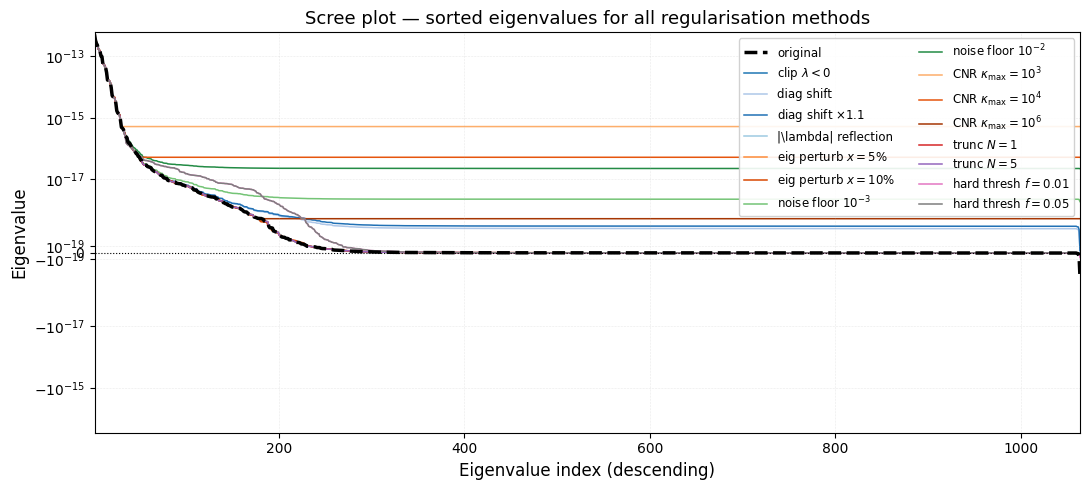

In [15]:
# ──────────────────────────────────────────────────────────────────────────────
# Figure 1: Scree plot  (Bickel & Levina 2008, Fig. 1 style)
# Sorted eigenvalues (descending) for every method on one axes.
# Symlog y-scale so both large positive and small negative values are visible.
# ──────────────────────────────────────────────────────────────────────────────

all_eigvals = {name: np.sort(np.linalg.eigvalsh(C_reg_all[name]))[::-1]
               for name in METHODS}

n_eig = len(C_orig)
idx   = np.arange(1, n_eig + 1)

# symlog threshold: 1e-6 × |λ_max| of the original
linthresh = 1e-6 * abs(all_eigvals['original'][0])

fig, ax = plt.subplots(figsize=(11, 5))

for name, ev in all_eigvals.items():
    lw   = 2.5 if name == 'original' else 1.1
    ls   = '--' if name == 'original' else '-'
    zord = 10  if name == 'original' else 1
    ax.plot(idx, ev,
            color=METHOD_COLORS[name], lw=lw, ls=ls,
            label=METHOD_LABELS[name], zorder=zord)

ax.axhline(0, color='k', lw=0.8, ls=':', zorder=5)
ax.set_yscale('symlog', linthresh=linthresh)
ax.set_xlabel('Eigenvalue index (descending)', fontsize=12)
ax.set_ylabel('Eigenvalue', fontsize=12)
ax.set_title(r'Scree plot — sorted eigenvalues for all regularisation methods', fontsize=13)
ax.set_xlim(1, n_eig)
ax.legend(ncol=2, fontsize=8.5, loc='upper right', framealpha=0.9)
ax.grid(True, which='both', ls=':', lw=0.4, alpha=0.5)

plt.tight_layout()
plt.savefig(FIGDIR / 'reg_scree.png', dpi=150, bbox_inches='tight')
plt.show()

/home/vtinnane/micromamba/envs/tSZxEuclid-godmax/lib/python3.11/site-packages/matplotlib/transforms.py:2437: RuntimeWarning: invalid value encountered in dot
  return Affine2D(np.dot(self._b.get_affine().get_matrix(),
/home/vtinnane/micromamba/envs/tSZxEuclid-godmax/lib/python3.11/site-packages/matplotlib/transforms.py:2437: RuntimeWarning: invalid value encountered in dot
  return Affine2D(np.dot(self._b.get_affine().get_matrix(),


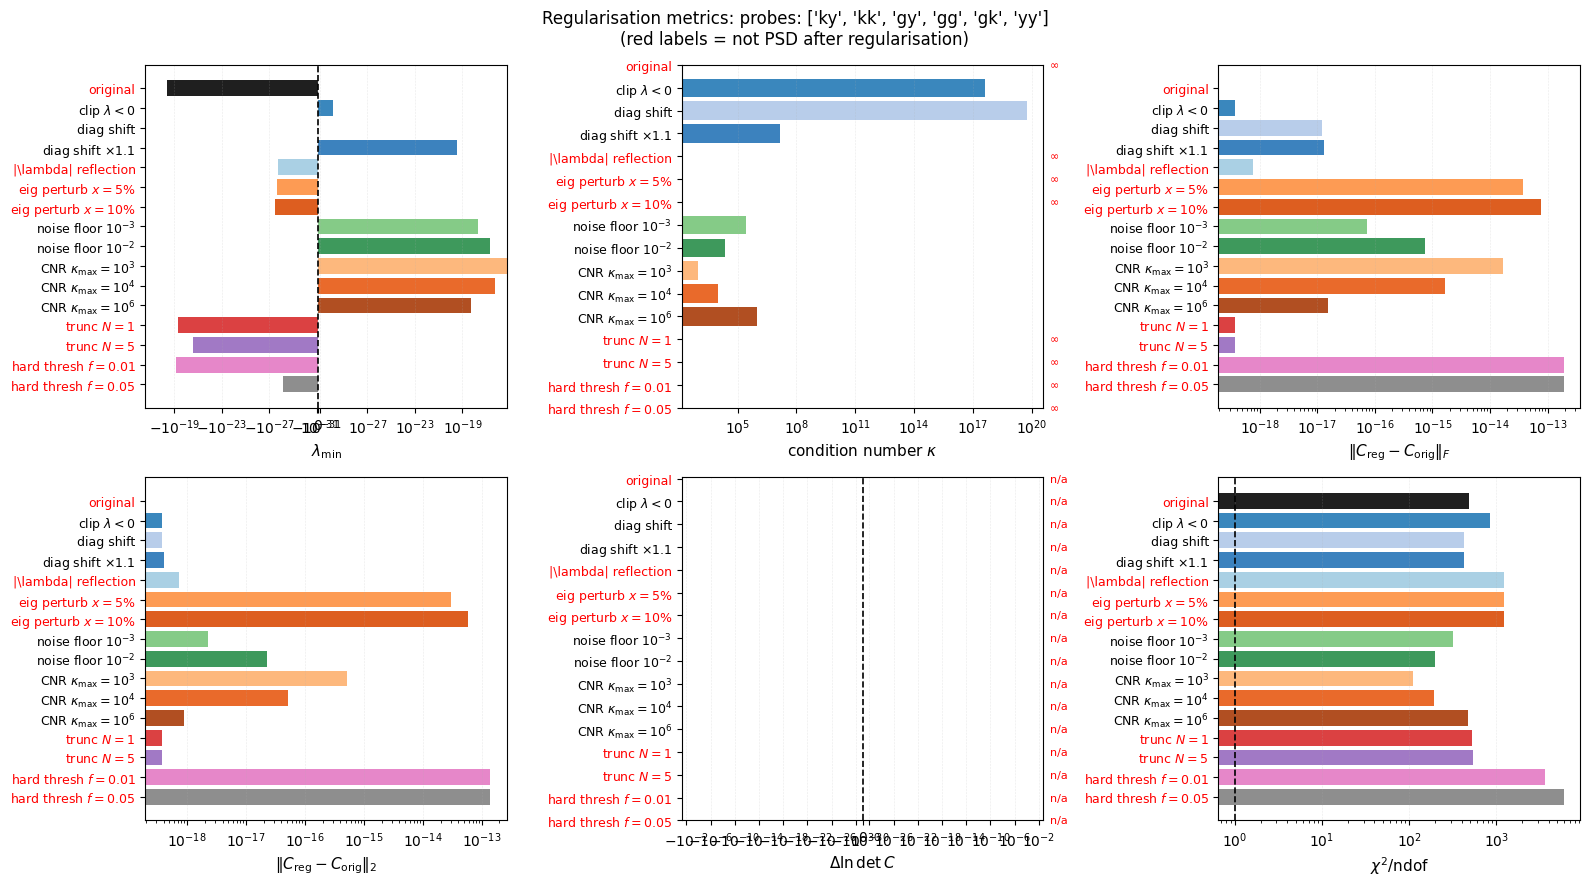

In [17]:
# ──────────────────────────────────────────────────────────────────────────────
# Figure 2: Metrics bar charts  (Chen et al. 2010 / Fortuna et al. 2021 style)
# 6 panels: λ_min, condition number, Frobenius norm, spectral norm,
#           Δ log det, χ²/ndof
# ──────────────────────────────────────────────────────────────────────────────

names  = list(METHODS.keys())
colors = [METHOD_COLORS[n] for n in names]
labels = [METHOD_LABELS[n] for n in names]
y      = np.arange(len(names))

metric_panels = [
    # (key,           x-label,                             scale,    reference line)
    ('lam_min',       r'$\lambda_{\min}$',                 'symlog', 0.0),
    ('cond',          r'condition number $\kappa$',        'log',    None),
    ('frob',          r'$\|C_{\rm reg}-C_{\rm orig}\|_F$', 'log',    None),
    ('spec',          r'$\|C_{\rm reg}-C_{\rm orig}\|_2$', 'log',    None),
    ('delta_logdet',  r'$\Delta\ln\det C$',                'symlog', 0.0),
    ('chi2_ndof',     r'$\chi^2/{\rm ndof}$',              'log',    1.0),
]

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flat

for ax, (key, xlabel, scale, refline) in zip(axes, metric_panels):
    vals = np.array([metrics[n][key] for n in names], dtype=float)

    # draw bars
    bar_colors = [METHOD_COLORS[n] for n in names]
    bars = ax.barh(y, vals, color=bar_colors, alpha=0.88, edgecolor='none')

    # reference line
    if refline is not None:
        ax.axvline(refline, color='k', lw=1.2, ls='--', zorder=5)

    # axis scale
    finite_pos = vals[np.isfinite(vals) & (vals > 0)]
    if scale == 'log' and len(finite_pos) > 0:
        ax.set_xscale('log')
    elif scale == 'symlog':
        finite_nz = vals[np.isfinite(vals) & (vals != 0)]
        lt = np.percentile(np.abs(finite_nz), 5) if len(finite_nz) > 0 else 1e-30
        ax.set_xscale('symlog', linthresh=max(lt, 1e-40))

    # annotate inf / nan
    xlim = ax.get_xlim()
    for i, (n, v) in enumerate(zip(names, vals)):
        if not np.isfinite(v):
            label_txt = '∞' if np.isinf(v) else 'n/a'
            ax.text(xlim[1], i, f'  {label_txt}', va='center', fontsize=8, color='red')

    ax.set_yticks(y)
    ax.set_yticklabels(labels, fontsize=9)
    ax.set_xlabel(xlabel, fontsize=11)
    ax.invert_yaxis()
    ax.grid(True, axis='x', ls=':', lw=0.4, alpha=0.5)

    # colour y-tick labels red if not PSD
    for tick, n in zip(ax.get_yticklabels(), names):
        if not metrics[n]['is_psd']:
            tick.set_color('red')

plt.suptitle(
    f'Regularisation metrics: probes: {probe_sets[11]}\n'
    r'(red labels = not PSD after regularisation)',
    fontsize=12,
)
plt.tight_layout()
plt.savefig(FIGDIR / 'reg_metrics.png', dpi=150, bbox_inches='tight')
plt.show()

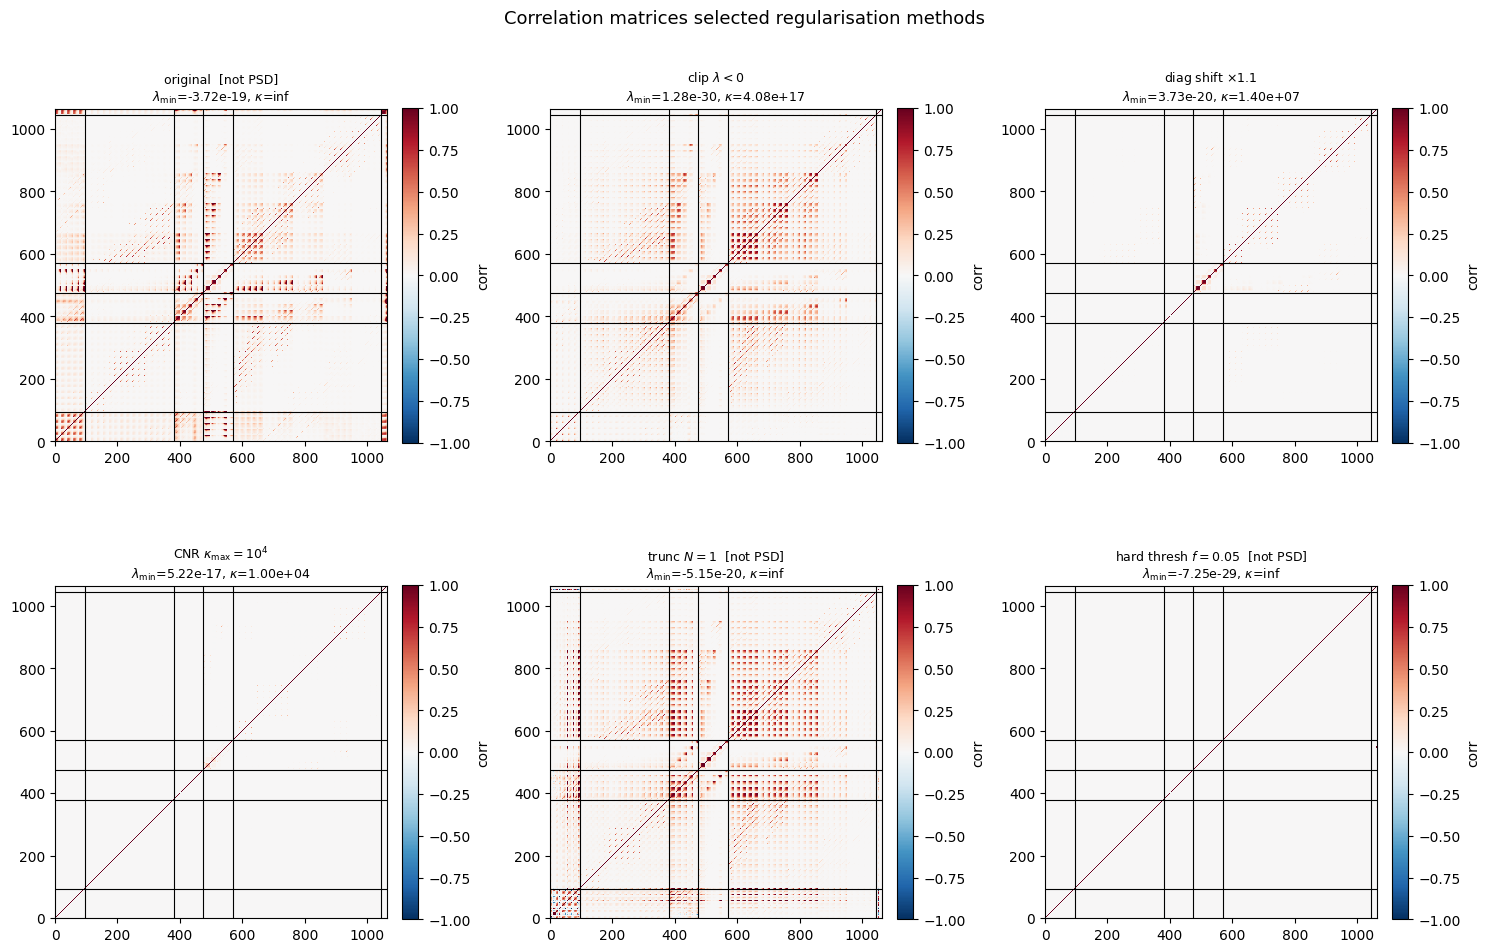

In [20]:
# ──────────────────────────────────────────────────────────────────────────────
# Figure 3: Correlation matrices  (selected methods)
# Shows how each method distorts the off-diagonal structure.
# ──────────────────────────────────────────────────────────────────────────────

def to_corr(C):
    d      = np.sqrt(np.maximum(np.diag(C), 0.0))
    d_safe = np.where(d > 0, d, 1.0)
    return C / np.outer(d_safe, d_safe)


show_methods = [
    'original', 'clip_neg0', 'diag_shift_x11',
    'cond_1e4', 'trunc_1',   'hard_s05',
]

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flat

for ax, name in zip(axes, show_methods):
    corr = to_corr(C_reg_all[name])
    im   = ax.imshow(corr, origin='lower', vmin=-1, vmax=1,
                     cmap='RdBu_r', interpolation='nearest')
    lam_min_val = metrics[name]['lam_min']
    psd_str     = '' if metrics[name]['is_psd'] else '  [not PSD]'
    ax.set_title(
        f"{METHOD_LABELS[name]}{psd_str}\n"
        r"$\lambda_{\min}$" + f"={lam_min_val:.2e}, "
        r"$\kappa$" + f"={metrics[name]['cond']:.2e}",
        fontsize=9,
    )
    # probe boundaries from full 6-probe covariance
    bounds = diag_utils.get_probe_boundaries(cov[11][2], cov[11][3])
    for edge in bounds['edges'][1:-1]:
        ax.axhline(edge - 0.5, color='k', lw=0.8)
        ax.axvline(edge - 0.5, color='k', lw=0.8)
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label='corr')

plt.suptitle('Correlation matrices selected regularisation methods', fontsize=13)
plt.tight_layout()
plt.savefig(FIGDIR / 'reg_corr.png', dpi=150, bbox_inches='tight')
plt.show()

Diagonal elements: 1064 total, 0 negative
  min diag = 1.281e-42,  max diag = 4.633e-13
Off-diagonal Cauchy-Schwarz violations (|rho|>1): 3904 / 1131032 (0.35%)
  max |rho_ij| = 119.2658

Worst |rho| per probe-pair block:
  ky  x ky : max|rho| = 0.8426
  ky  x kk : max|rho| = 0.3111
  ky  x gy : max|rho| = 0.7443
  ky  x gg : max|rho| = 4.9978  *** VIOLATION
  ky  x gk : max|rho| = 0.5963
  ky  x yy : max|rho| = 0.7750
  kk  x kk : max|rho| = 0.8493
  kk  x gy : max|rho| = 0.3020
  kk  x gg : max|rho| = 0.6747
  kk  x gk : max|rho| = 0.8673
  kk  x yy : max|rho| = 0.1238
  gy  x gy : max|rho| = 0.9719
  gy  x gg : max|rho| = 10.4488  *** VIOLATION
  gy  x gk : max|rho| = 1.1140  *** VIOLATION
  gy  x yy : max|rho| = 5.4213  *** VIOLATION
  gg  x gg : max|rho| = 0.9998
  gg  x gk : max|rho| = 3.6386  *** VIOLATION
  gg  x yy : max|rho| = 119.2658  *** VIOLATION
  gk  x gk : max|rho| = 0.8638
  gk  x yy : max|rho| = 2.1819  *** VIOLATION
  yy  x yy : max|rho| = 0.9948

Negative eigenvalu

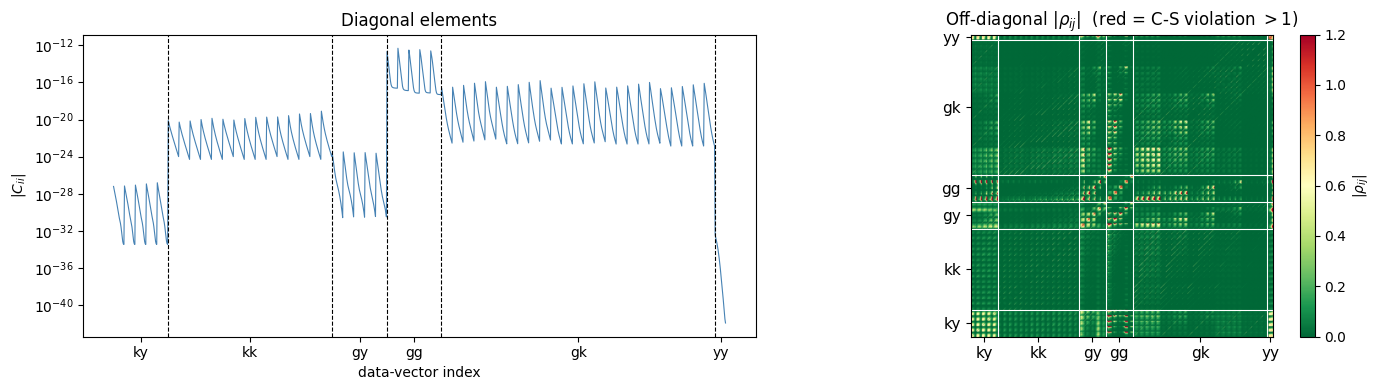

In [21]:
# ══════════════════════════════════════════════════════════════════════
#  NON-DIAGONAL INVESTIGATION
#  Three questions:
#   1. Are any diagonal elements of C negative?
#   2. Which off-diagonal (probe_i × probe_j) ell-pairs violate
#      the Cauchy-Schwarz condition  C_ii * C_jj < C_ij² ?
#   3. Which probes does the negative eigenspace project onto?
# ══════════════════════════════════════════════════════════════════════

# use the full 6-probe covariance (index 11 in probe_sets)
C_raw, entries_raw, cpp_raw, nell_raw = cov[11]
n_total = C_raw.shape[0]
probes_raw = probe_sets[11]

# ── 1. Diagonal elements ─────────────────────────────────────────────
diag_C = np.diag(C_raw)
n_neg_diag = np.sum(diag_C < 0)
print(f'Diagonal elements: {len(diag_C)} total, {n_neg_diag} negative')
print(f'  min diag = {diag_C.min():.3e},  max diag = {diag_C.max():.3e}')

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].semilogy(np.arange(len(diag_C)), np.abs(diag_C),
                 lw=0.8, color='steelblue')
if n_neg_diag > 0:
    neg_idx = np.where(diag_C < 0)[0]
    axes[0].scatter(neg_idx, np.abs(diag_C[neg_idx]),
                    color='red', s=10, zorder=5, label='negative')
    axes[0].legend()
# probe boundaries
bounds = diag_utils.get_probe_boundaries(cpp_raw, nell_raw)
for e in bounds['edges'][1:-1]:
    axes[0].axvline(e - 0.5, color='k', lw=0.8, ls='--')
axes[0].set_xticks(bounds['centers'])
axes[0].set_xticklabels(probes_raw)
axes[0].set_xlabel('data-vector index')
axes[0].set_ylabel(r'$|C_{ii}|$')
axes[0].set_title('Diagonal elements')

# ── 2. Cauchy-Schwarz violations  C_ii * C_jj < C_ij^2 ──────────────
# compute ratio r_ij = C_ij / sqrt(|C_ii * C_jj|)  (= correlation coeff)
d_safe = np.where(np.abs(diag_C) > 0, np.abs(diag_C), 1.0)
corr_mat = C_raw / np.sqrt(np.outer(d_safe, d_safe))
# off-diagonal violations: |corr| > 1
mask_off = ~np.eye(n_total, dtype=bool)
abs_corr_off = np.abs(corr_mat[mask_off])
n_viol = np.sum(abs_corr_off > 1.0)
print(f'Off-diagonal Cauchy-Schwarz violations (|rho|>1): {n_viol} '
      f'/ {mask_off.sum()} ({100*n_viol/mask_off.sum():.2f}%)')
print(f'  max |rho_ij| = {abs_corr_off.max():.4f}')

# worst violation per probe-pair block
print('\nWorst |rho| per probe-pair block:')
edges = [int(e) for e in bounds['edges']]
for ip1, p1 in enumerate(probes_raw):
    s1 = slice(edges[ip1], edges[ip1+1])
    for ip2 in range(ip1, len(probes_raw)):
        p2 = probes_raw[ip2]
        s2 = slice(edges[ip2], edges[ip2+1])
        block = corr_mat[s1, s2]
        if ip1 == ip2:
            # diagonal block: off-diagonal elements only
            vals = np.abs(block[~np.eye(block.shape[0], dtype=bool)])
        else:
            vals = np.abs(block.ravel())
        if len(vals):
            worst = vals.max()
            flag = '  *** VIOLATION' if worst > 1.0 else ''
            print(f'  {p1:3s} x {p2:3s}: max|rho| = {worst:.4f}{flag}')

# ── 3. Negative-eigenspace probe projection ───────────────────────────
eigvals, eigvecs = np.linalg.eigh(C_raw)
neg_mask = eigvals < 0
print(f'\nNegative eigenvalues: {neg_mask.sum()}')
if neg_mask.sum() > 0:
    print(f'  range [{eigvals[neg_mask].min():.3e}, {eigvals[neg_mask].max():.3e}]')
    # for each negative eigenvector: squared projection per probe block
    V_neg = eigvecs[:, neg_mask]   # (n_total, n_neg)
    proj = np.zeros((len(probes_raw), neg_mask.sum()))
    for ip, p in enumerate(probes_raw):
        s = slice(edges[ip], edges[ip+1])
        proj[ip] = np.sum(V_neg[s]**2, axis=0)
    # mean squared projection per probe
    mean_proj = proj.mean(axis=1)
    print('  Mean squared projection of negative eigenvectors per probe:')
    for p, mp in zip(probes_raw, mean_proj):
        bar = '█' * int(mp * 50)
        print(f'    {p:3s}: {mp:.4f}  {bar}')

# violation heatmap
viol_map = np.abs(corr_mat.copy())
np.fill_diagonal(viol_map, 0)   # hide diagonal
im = axes[1].imshow(viol_map, vmin=0, vmax=1.2, cmap='RdYlGn_r',
                    origin='lower')
plt.colorbar(im, ax=axes[1], label=r'$|\rho_{ij}|$', fraction=0.046, pad=0.04)
for e in bounds['edges'][1:-1]:
    axes[1].axhline(e - 0.5, color='white', lw=0.8)
    axes[1].axvline(e - 0.5, color='white', lw=0.8)
axes[1].set_xticks(bounds['centers']); axes[1].set_xticklabels(probes_raw, fontsize=11)
axes[1].set_yticks(bounds['centers']); axes[1].set_yticklabels(probes_raw, fontsize=11)
axes[1].set_title(r'Off-diagonal $|\rho_{ij}|$  (red = C-S violation $>1$)')
fig.tight_layout()
plt.savefig(str(FIGDIR / 'cov_nondiago_diag.png'), dpi=150, bbox_inches='tight')
plt.show()


In [23]:
# ══════════════════════════════════════════════════════════════════════
#  REGULARISATION SELECTION CRITERIA
#  A method is 'best' if it simultaneously satisfies:
#    C1. PSD              — lambda_min > 0  (necessary)
#    C2. Condition number — kappa < 1e8     (numerical safety)
#    C3. Fidelity         — ||C_reg - C||_F / ||C||_F minimal
#    C4. Diagonal fidelity— max |diag(C_reg)/diag(C) - 1| minimal
#    C5. Mock chi2        — chi2/ndof ~ 1   (statistical validity)
#    C6. Correlation preservation — mean|rho_reg - rho_orig| minimal
# ══════════════════════════════════════════════════════════════════════

import pandas as pd

C0 = cov[11][0].copy()   # raw full covariance
n  = C0.shape[0]

# fiducial data vector (signal only) for chi2 mock
dv_fid = datavec[11][0].copy()

# correlation matrix of raw covariance
d0    = np.abs(np.diag(C0))
d0s   = np.where(d0 > 0, d0, 1.0)
rho0  = C0 / np.sqrt(np.outer(d0s, d0s))
mask_off = ~np.eye(n, dtype=bool)

norm_F0 = np.linalg.norm(C0, 'fro')

rows = []
for key, kwargs in METHODS.items():
    Cr = regularise(C0, **kwargs)
    ev = np.linalg.eigvalsh(Cr)
    lmin = ev.min()
    lmax = ev.max()

    # C1: PSD
    psd = bool(lmin > 0)

    # C2: condition number
    kappa = lmax / lmin if lmin > 0 else np.inf

    # C3: Frobenius fidelity
    fid_F = np.linalg.norm(Cr - C0, 'fro') / norm_F0

    # C4: diagonal fidelity
    dr    = np.abs(np.diag(Cr))
    fid_diag = np.max(np.abs(dr / d0s - 1.0))

    # C5: mock chi2 — draw mock from C0, compute chi2 with C_reg^-1
    try:
        rng  = np.random.default_rng(42)
        mock = rng.multivariate_normal(dv_fid, C0, size=200)
        Cinv = np.linalg.inv(Cr)
        resid = mock - dv_fid[None, :]
        chi2s = np.einsum('ni,ij,nj->n', resid, Cinv, resid)
        chi2_ndof = float(chi2s.mean()) / n
    except np.linalg.LinAlgError:
        chi2_ndof = np.inf

    # C6: correlation preservation
    drs  = np.where(dr > 0, dr, 1.0)
    rho_r = Cr / np.sqrt(np.outer(drs, drs))
    fid_rho = float(np.mean(np.abs((rho_r - rho0)[mask_off])))

    rows.append(dict(
        method    = key,
        psd       = psd,
        kappa     = kappa,
        fid_F     = fid_F,
        fid_diag  = fid_diag,
        chi2_ndof = chi2_ndof,
        fid_rho   = fid_rho,
    ))

df = pd.DataFrame(rows).set_index('method')

# ── scoring: rank each numeric criterion, sum ranks ──────────────────
# lower is better for kappa, fid_F, fid_diag, |chi2-1|, fid_rho
df_psd = df[df['psd']].copy()
df_psd['rank_kappa']    = df_psd['kappa'].rank()
df_psd['rank_fid_F']    = df_psd['fid_F'].rank()
df_psd['rank_fid_diag'] = df_psd['fid_diag'].rank()
df_psd['rank_chi2']     = (df_psd['chi2_ndof'] - 1.0).abs().rank()
df_psd['rank_fid_rho']  = df_psd['fid_rho'].rank()
df_psd['total_rank']    = (df_psd[['rank_kappa','rank_fid_F',
                                    'rank_fid_diag','rank_chi2',
                                    'rank_fid_rho']].sum(axis=1))
best = df_psd['total_rank'].idxmin()

print('Selection criteria (PSD methods only):')
print('  C1 PSD          — lambda_min > 0')
print('  C2 kappa        — condition number (lower is safer)')
print('  C3 fid_F        — Frobenius distance / ||C||_F (lower = less distortion)')
print('  C4 fid_diag     — max relative diagonal change (lower = variances preserved)')
print('  C5 chi2/ndof    — mock chi2 with 200 realisations (want ~1)')
print('  C6 fid_rho      — mean |Delta rho| off-diagonal (lower = correlations preserved)')
print(f'\n  ==> Best method by sum-of-ranks: {best}')

# build display df: base cols from df, add total_rank from df_psd (NaN for non-PSD)
display_cols = ['psd','kappa','fid_F','fid_diag','chi2_ndof','fid_rho']
df_show = df[display_cols].copy()
df_show['total_rank'] = np.nan
df_show.loc[df_psd.index, 'total_rank'] = df_psd['total_rank'].values

def _style(v, col):
    if col == 'psd':
        return 'color: green' if v else 'color: red'
    if col == 'total_rank' and pd.notna(v):
        mn = df_psd['total_rank'].min()
        if v == mn: return 'background-color: #c6efce; font-weight: bold'
    return ''

styled = (df_show.style
    .format({'kappa': '{:.2e}', 'fid_F': '{:.4f}',
             'fid_diag': '{:.4f}', 'chi2_ndof': '{:.4f}',
             'fid_rho': '{:.4f}', 'total_rank': '{:.0f}'})
    .apply(lambda col: [_style(v, col.name) for v in col], axis=0)
    .set_caption('Regularisation selection criteria — green highlight = best by sum-of-ranks')
)
display(styled)


Selection criteria (PSD methods only):
  C1 PSD          — lambda_min > 0
  C2 kappa        — condition number (lower is safer)
  C3 fid_F        — Frobenius distance / ||C||_F (lower = less distortion)
  C4 fid_diag     — max relative diagonal change (lower = variances preserved)
  C5 chi2/ndof    — mock chi2 with 200 realisations (want ~1)
  C6 fid_rho      — mean |Delta rho| off-diagonal (lower = correlations preserved)

  ==> Best method by sum-of-ranks: cond_1e6


,psd,kappa,fid_F,fid_diag,chi2_ndof,fid_rho,total_rank
method,,,,,,,
original,False,inf,0.0000,0.0000,1124780344508.0752,0.0000,nan
clip_neg0,True,4.08e+17,0.0000,90482024187154.4219,3952416.8490,0.0437,21
diag_shift,True,5.68e+19,0.0000,290427232445648911466496.0000,127445523595.4158,0.0431,22
diag_shift_x11,True,1.40e+07,0.0000,319510705171236835557376.0000,0.1878,0.0432,17
lam_abs,False,inf,0.0000,222992.8978,225034178719.9295,0.0527,nan
eig_perturb_5,False,inf,0.0482,90482024201597.4531,0.9281,0.0524,nan
eig_perturb_10,False,inf,0.0964,90482024201578.8906,0.9362,0.0529,nan
noise_floor_01p,True,2.77e+05,0.0001,1760537100669868159533056.0000,0.1263,0.0436,21
noise_floor_1p,True,2.35e+04,0.0009,17605371006698691259006976.0000,0.0687,0.0443,25


METHOD A: diagonal shift by |lambda_min|
  lambda_min = -3.720e-19   shift = 3.720e-19
  mean relative perturbation : 400320678018206990336.0000
  threshold (2x mean)        : 800641356036413980672.0000
  fraction exceeding threshold: 0.004  (PASS < 40%)

METHOD B: eigenvalue perturbation
  x =   5.0%:  PSD=False  frac_all<10% = 0.245  (FAIL < 80%)
           frac_diag<10% = 0.552  lambda_min = -2.143e-28
  x =  10.0%:  PSD=False  frac_all<10% = 0.190  (FAIL < 80%)
           frac_diag<10% = 0.532  lambda_min = -3.575e-28
  x =  20.0%:  PSD=False  frac_all<10% = 0.127  (FAIL < 80%)
           frac_diag<10% = 0.450  lambda_min = -1.119e-28


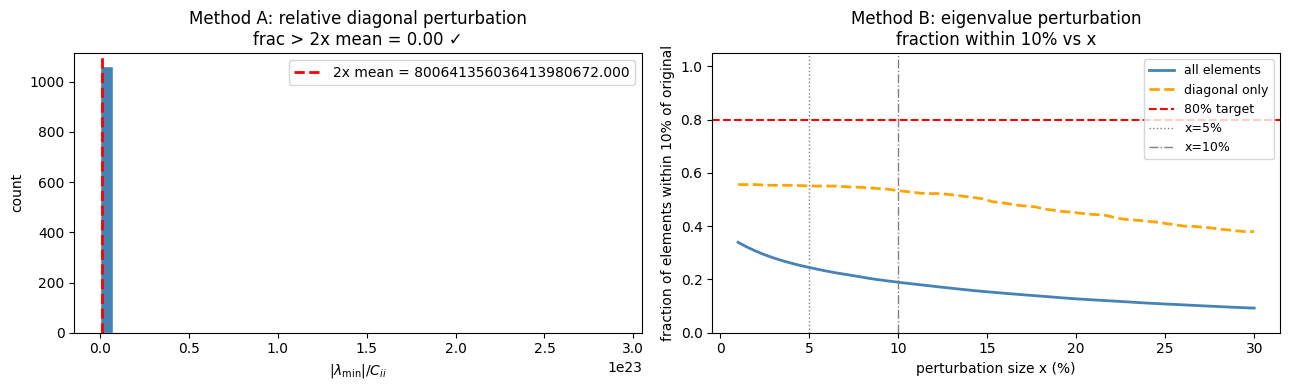

In [24]:
# ══════════════════════════════════════════════════════════════════════
#  PAPER METHOD TESTS
#
#  Method A — diagonal shift by |lambda_min|  (diag_shift)
#    Check: fraction of diagonal elements where relative perturbation
#    exceeds 2 x mean relative perturbation  <  40%
#    i.e.  frac( |lambda_min| / C_ii  >  2 * mean(|lambda_min|/C_ii) )  < 0.4
#
#  Method B — eigenvalue perturbation  (eig_perturb)
#    C = Q Λ Q^T  ->  lambda_new = |lambda| * (1 + delta)
#    delta ~ N(0, x/100), |delta| < 1
#    Check: >= 80% of matrix elements within 10% of original
# ══════════════════════════════════════════════════════════════════════

C0   = cov[11][0].copy()
n    = C0.shape[0]
diag = np.diag(C0)

print('=' * 60)
print('METHOD A: diagonal shift by |lambda_min|')
print('=' * 60)

ev0    = np.linalg.eigvalsh(C0)
lmin   = ev0.min()
shift  = abs(lmin) if lmin < 0 else 0.0
print(f'  lambda_min = {lmin:.3e}   shift = {shift:.3e}')

if shift > 0:
    # relative perturbation per diagonal element
    rel_pert = shift / np.abs(diag)        # |lambda_min| / C_ii
    mean_rel = rel_pert.mean()
    threshold = 2.0 * mean_rel
    frac_exceed = np.mean(rel_pert > threshold)
    print(f'  mean relative perturbation : {mean_rel:.4f}')
    print(f'  threshold (2x mean)        : {threshold:.4f}')
    print(f'  fraction exceeding threshold: {frac_exceed:.3f}  '
          + ('(PASS < 40%)' if frac_exceed < 0.4 else '(FAIL >= 40%)'))

    # distribution of relative perturbations
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    axes[0].hist(rel_pert, bins=40, color='steelblue', edgecolor='white')
    axes[0].axvline(threshold, color='red', lw=2, ls='--',
                    label=f'2x mean = {threshold:.3f}')
    axes[0].set_xlabel(r'$|\lambda_{\min}| / C_{ii}$')
    axes[0].set_ylabel('count')
    axes[0].set_title(f'Method A: relative diagonal perturbation\n'
                      f'frac > 2x mean = {frac_exceed:.2f} '
                      + ('✓' if frac_exceed < 0.4 else '✗'))
    axes[0].legend()
else:
    print('  Matrix already PSD — no shift needed.')
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))

print()
print('=' * 60)
print('METHOD B: eigenvalue perturbation')
print('=' * 60)

results_B = []
for x_pct in [5.0, 10.0, 20.0]:
    key = 'eig_perturb_5' if x_pct == 5.0 else ('eig_perturb_10' if x_pct == 10.0 else None)
    C_reg = regularise(C0, method='eig_perturb', x=x_pct, seed=42)

    # check PSD
    ev_reg  = np.linalg.eigvalsh(C_reg)
    is_psd  = bool(ev_reg.min() > 0)

    # fraction of elements within 10% of original
    rel_diff = np.abs((C_reg - C0) / (np.abs(C0) + 1e-300))
    frac_10  = float(np.mean(rel_diff < 0.10))

    # fraction of DIAGONAL elements within 10%
    rel_diag = np.abs((np.diag(C_reg) - diag) / (np.abs(diag) + 1e-300))
    frac_diag_10 = float(np.mean(rel_diag < 0.10))

    print(f'  x = {x_pct:5.1f}%:  PSD={is_psd}  '
          f'frac_all<10% = {frac_10:.3f}  '
          + ('(PASS >= 80%)' if frac_10 >= 0.8 else '(FAIL < 80%)'))
    print(f'           frac_diag<10% = {frac_diag_10:.3f}  '
          f'lambda_min = {ev_reg.min():.3e}')
    results_B.append((x_pct, frac_10, frac_diag_10))

# plot: frac within 10% vs perturbation size
xs    = np.linspace(1, 30, 60)
fracs_all  = []
fracs_diag = []
for xv in xs:
    Ct = regularise(C0, method='eig_perturb', x=float(xv), seed=42)
    rd = np.abs((Ct - C0) / (np.abs(C0) + 1e-300))
    fracs_all.append(float(np.mean(rd < 0.10)))
    rdd = np.abs((np.diag(Ct) - diag) / (np.abs(diag) + 1e-300))
    fracs_diag.append(float(np.mean(rdd < 0.10)))

axes[1].plot(xs, fracs_all,  color='steelblue', lw=2, label='all elements')
axes[1].plot(xs, fracs_diag, color='orange',    lw=2, label='diagonal only', ls='--')
axes[1].axhline(0.80, color='red', lw=1.5, ls='--', label='80% target')
axes[1].axvline(5.0,  color='grey', lw=1,  ls=':',  label='x=5%')
axes[1].axvline(10.0, color='grey', lw=1,  ls='-.',  label='x=10%')
axes[1].set_xlabel('perturbation size x (%)')
axes[1].set_ylabel('fraction of elements within 10% of original')
axes[1].set_title('Method B: eigenvalue perturbation\nfraction within 10% vs x')
axes[1].legend(fontsize=9)
axes[1].set_ylim(0, 1.05)
fig.tight_layout()
plt.savefig(str(FIGDIR / 'cov_paper_methods.png'), dpi=150, bbox_inches='tight')
plt.show()


#### Inference setup  mixed HOD + gas parameters

Cosmology is fixed.  Eight free parameters split across the galaxy and gas sectors
so that each probe carries distinct information.

---

##### Galaxy sector - sensitive probes: `gg`, `gy`

| Parameter | Fiducial | Physical meaning |
|-----------|----------|-----------------|
| `log10M1_fshmr` | 12.35 | log₁₀ of the **pivot halo mass** M₁ [M☉/h] where the SHMR peaks.  Sets the effective large-scale galaxy bias; enters both `gg` (directly) and `gy` (via b_g in the 2-halo term). |
| `gamma_fshmr` | 1.56 | **High-mass SHMR slope**  M★ ∝ M^γ above M₁.  Cluster-scale halos are both high-bias (affects `gg`) and tSZ-bright (affects `gy`); the one SHMR parameter that couples strongly to both probes. |
| `Bsat_Nsat` | 9.01 | **Satellite occupation amplitude**  overall scaling of ⟨N_sat\|M⟩.  Dominant driver of the `gg` 1-halo term; satellites in massive halos also boost the `gy` 1-halo term. |
| `alphasat_Nsat` | 1.0 | **Satellite power-law slope**  ⟨N_sat⟩ ∝ (M/M_sat)^α.  Controls how steeply satellite counts rise with halo mass; shapes the `gg` 1-halo term at high ℓ. |

##### Gas sector - sensitive probes: `gy`, `yy`

| Parameter | Fiducial | Physical meaning |
|-----------|----------|-----------------|
| `theta_ej_0` | 2.0 | **Ejection radius** θ_ej = r_ej / r_200c.  Controls how far AGN feedback expels gas beyond the halo virial radius.  The dominant amplitude parameter for both `yy` and `gy`. |
| `log10_Mc0` | — | log₁₀ of the **gas-retention characteristic mass** M_c [M☉/h].  Below M_c halos lose most of their gas to feedback; above it they retain it.  Sets the mass-scale turnover of the gas fraction and hence the `yy` + `gy` amplitude. |
| `gamma_rhogas` | 2.0 | **Outer gas density slope**  ρ_gas ∝ r^{−γ} at large radii.  Controls how steeply the gas profile falls beyond the core; shapes the `yy` power spectrum at intermediate ℓ and the `gy` cross-spectrum. |
| `mu_beta` | 0.6 | **Central β-slope** of the BCMP gas profile.  β sets the logarithmic slope of the pressure profile between the core and the ejection radius.  Primarily a `yy`-shape parameter with weak effect on `gy`. |

---

**Probes:** `['gg']`, `['gy']`, `['yy']`, `['gg','gy','yy']`  ·  **Regularisation:** `lam_abs` (|λ| reflection)


In [25]:
# =====================================================================
#   8 INTRINSIC HOD + GAS PARAMETERS
#   Galaxy (5): log10M1, log10Mstar0, gamma_fshmr, Bsat, alphasat
#               → M1 + Mstar0 together fix the effective log M_min
#   Gas    (3): theta_ej, log10_Mc0, gamma_rhogas
# =====================================================================
param_names = [
    'log10M1_fshmr',       # pivot halo mass (SHMR)
    'log10Mstar0_fshmr',   # characteristic stellar mass → effective M_min
    'gamma_fshmr',         # high-mass SHMR slope
    'Bsat_Nsat',           # satellite occupation amplitude
    'alphasat_Nsat',       # satellite power-law slope
    'theta_ej_0',          # gas ejection radius
    'log10_Mc0',           # gas retention mass scale
    'gamma_rhogas',        # outer gas density slope
]

prior_min = {
    'log10M1_fshmr':     11.5,
    'log10Mstar0_fshmr':  9.5,
    'gamma_fshmr':        0.5,
    'Bsat_Nsat':          1.0,
    'alphasat_Nsat':      0.5,
    'theta_ej_0':         0.5,
    'log10_Mc0':          9.0,
    'gamma_rhogas':       0.5,
}
prior_max = {
    'log10M1_fshmr':     13.5,
    'log10Mstar0_fshmr': 11.5,
    'gamma_fshmr':        4.0,
    'Bsat_Nsat':         30.0,
    'alphasat_Nsat':      2.0,
    'theta_ej_0':         8.0,
    'log10_Mc0':         16.0,
    'gamma_rhogas':       5.0,
}

theta_fid_dict = {p: float(sim_params_dict[p]) for p in param_names}
theta_fid_vec  = jnp.array([theta_fid_dict[p] for p in param_names])

latex_labels = {
    'log10M1_fshmr':     r'\log_{10}M_1',
    'log10Mstar0_fshmr': r'\log_{10}M_{\star,0}',
    'gamma_fshmr':       r'\gamma_{\rm SHMR}',
    'Bsat_Nsat':         r'B_{\rm sat}',
    'alphasat_Nsat':     r'\alpha_{\rm sat}',
    'theta_ej_0':        r'\theta_{\rm ej,0}',
    'log10_Mc0':         r'\log_{10}M_c',
    'gamma_rhogas':      r'\gamma_{\rho_{\rm gas}}',
}

# Single regularisation method
REG_METHOD = 'lam_abs'
METHODS['lam_abs'] = dict(method='lam_abs')

# Jacobian step sizes
_EPS_JAC = {
    'log10M1_fshmr':     0.1,
    'log10Mstar0_fshmr': 0.1,
    'gamma_fshmr':       0.05,
    'Bsat_Nsat':         0.5,
    'alphasat_Nsat':     0.05,
    'theta_ej_0':        0.1,
    'log10_Mc0':         0.2,
    'gamma_rhogas':      0.1,
}

print('8 intrinsic HOD + gas parameters:')
for p in param_names:
    print(f'  {p:22s}: [{prior_min[p]:6.2f}, {prior_max[p]:6.2f}]  fid={theta_fid_dict[p]:.4f}')
print(f'Regularisation: {REG_METHOD}')


8 intrinsic HOD + gas parameters:
  log10M1_fshmr         : [ 11.50,  13.50]  fid=12.5500
  log10Mstar0_fshmr     : [  9.50,  11.50]  fid=10.7200
  gamma_fshmr           : [  0.50,   4.00]  fid=1.7900
  Bsat_Nsat             : [  1.00,  30.00]  fid=9.0100
  alphasat_Nsat         : [  0.50,   2.00]  fid=1.1900
  theta_ej_0            : [  0.50,   8.00]  fid=2.0000
  log10_Mc0             : [  9.00,  16.00]  fid=10.7500
  gamma_rhogas          : [  0.50,   5.00]  fid=2.0000
Regularisation: lam_abs


In [26]:
import arviz as az


def _extract_for_entries(cls_obj, entries, nell):
    """Extract flat data vector from a get_Cl object given an entries list."""
    out = np.zeros(len(entries) * nell)
    for idx, (prb, (b1, b2)) in enumerate(entries):
        sl = slice(idx * nell, (idx + 1) * nell)
        if   prb == 'yy': out[sl] = np.array(cls_obj.Cl_y_y_tot_mat)
        elif prb == 'ky': out[sl] = np.array(cls_obj.Cl_kappa_y_tot_mat[:, b1-1])
        elif prb == 'kk': out[sl] = np.array(cls_obj.Cl_kappa_kappa_tot_mat[:, b1-1, b2-1])
        elif prb == 'gg': out[sl] = np.array(cls_obj.Cl_gal_gal_tot_mat[:, b1-1, b2-1])
        elif prb == 'gk': out[sl] = np.array(cls_obj.Cl_gal_kappa_tot_mat[:, b1-1, b2-1])
        elif prb == 'gy': out[sl] = np.array(cls_obj.Cl_gal_y_tot_mat[:, b1-1])
    return out


def run_inference(
    probes_arr,
    cov_obj,
    jac_in,
    entries_in,
    probe_label,
    probe_color,
    reg_method = REG_METHOD,
    n_warmup   = 500,
    n_samples  = 2000,
    rng_seed   = 42,
    bin_selection = None,
):
    """Run linearised NUTS for one probe set with one regularisation method.

    Parameters
    ----------
    probes_arr   : list of str  e.g. ['gg'] or ['gy', 'gg']
    cov_obj      : get_cov instance (fiducial)
    jac_in       : ndarray (n_dv, n_params) pre-computed Jacobian
    entries_in   : list of [probe, [b1, b2]] data-vector entries
    probe_label  : str  label for plots
    probe_color  : str  matplotlib colour
    reg_method   : str  key in METHODS dict

    Returns
    -------
    MCSamples object  (getdist), also prints summary
    """
    import copy, time
    import jax as _jax
    import jax.numpy as _jnp
    import numpyro
    import numpyro.distributions as dist
    from numpyro.infer import NUTS, MCMC
    from getdist import MCSamples

    # ── data vector & raw covariance ─────────────────────────────────────
    data_vec, _, _ = diag_utils.build_data_vector(
        cov_obj.Cl_result_dict, probes_arr,
        key='tot_ellsurvey', bin_selection=bin_selection,
    )
    cov_raw, _, _, _ = diag_utils.build_cov_matrix(
        cov_obj.covtot_dict, cov_obj.Cl_result_dict, probes_arr,
        bin_selection=bin_selection, symmetrize=True,
    )
    data_np = np.array(data_vec, dtype=float)
    T_fid   = data_np.copy()

    # ── regularise covariance ────────────────────────────────────────────
    cov_reg = regularise(cov_raw, **METHODS[reg_method])
    cov_inv = np.linalg.inv(cov_reg)
    lam_min = np.linalg.eigvalsh(cov_reg).min()
    cond    = np.linalg.eigvalsh(cov_reg).max() / lam_min if lam_min > 0 else np.inf
    print(f'  [{probe_label}]  n_dv={len(data_np)}  '
          f'reg={reg_method}  lambda_min={lam_min:.2e}  cond={cond:.2e}')

    # ── NUTS ─────────────────────────────────────────────────────────────
    jac_jnp       = _jnp.array(jac_in)
    T_fid_jnp     = _jnp.array(T_fid)
    data_jnp      = _jnp.array(data_np)
    cov_inv_jnp   = _jnp.array(cov_inv)
    theta_fid_jnp = _jnp.array([float(theta_fid_dict[p]) for p in param_names])

    def _model():
        theta = _jnp.stack([
            numpyro.sample(p, dist.Uniform(prior_min[p], prior_max[p]))
            for p in param_names
        ])
        diff = data_jnp - (T_fid_jnp + jac_jnp @ (theta - theta_fid_jnp))
        numpyro.factor('loglike', -0.5 * diff @ cov_inv_jnp @ diff)

    # sanity: log_p at fiducial should be 0
    try:
        lp = numpyro.infer.util.log_density(
            _model, (), {}, {p: float(theta_fid_dict[p]) for p in param_names}
        )[0]
        # log_p = log_likelihood + log_prior_normalisation
        # At fiducial: log_likelihood=0, log_prior = -sum_p log(b_p - a_p)
        log_prior_norm = -sum(np.log(prior_max[p] - prior_min[p]) for p in param_names)
        print(f'    log_p(theta_fid) = {float(lp):.4f}  '
              f'(log_like=0 + log_prior_norm={log_prior_norm:.4f})')
    except Exception as e:
        print(f'    [warn] log_density check: {e}')

    mcmc = MCMC(
        NUTS(_model, dense_mass=True, adapt_mass_matrix=True,
             adapt_step_size=True, max_tree_depth=8),
        num_warmup=n_warmup, num_samples=n_samples,
        num_chains=1, progress_bar=True,
    )
    t0 = time.time()
    mcmc.run(_jax.random.PRNGKey(rng_seed))
    elapsed = time.time() - t0

    samps   = mcmc.get_samples()
    idata   = az.from_numpyro(mcmc)
    summary = az.summary(idata, var_names=param_names)
    print(f'    {elapsed:.1f}s  |  R-hat max = {summary["r_hat"].max():.4f}')
    print(summary[['mean', 'sd', 'r_hat']].to_string())

    arr = np.column_stack([np.array(samps[p]) for p in param_names])
    return MCSamples(
        samples=arr,
        names=param_names,
        labels=[latex_labels[p] for p in param_names],
        label=probe_label,
        settings={'smooth_scale_2D': 0.4, 'smooth_scale_1D': 0.4},
    )


def _triangle_plot(gd_list, colors, title, fname, param_limits=None):
    """Shared triangle-plot helper (getdist)."""
    from getdist import plots as gd_plots
    import os
    fiducials = [float(theta_fid_dict[p]) for p in param_names]
    n_p       = len(param_names)
    _lws      = [2.0] * len(gd_list)
    g = gd_plots.get_subplot_plotter(width_inch=12)
    g.settings.figure_legend_frame = False
    g.settings.legend_fontsize     = 11
    g.triangle_plot(
        gd_list, param_names,
        filled=True,
        contour_colors=colors,
        contour_lws=_lws,
        title_limit=1,
        param_limits=param_limits,
        legend_loc='upper right',
    )
    for row in range(n_p):
        for col in range(row + 1):
            ax = g.subplots[row, col]
            if ax is None: continue
            if row == col:
                ax.axvline(fiducials[col], color='k', ls='--', lw=1.5, zorder=5)
            else:
                ax.axvline(fiducials[col], color='k', ls='--', lw=1.0, zorder=5)
                ax.axhline(fiducials[row], color='k', ls='--', lw=1.0, zorder=5)
                ax.plot(fiducials[col], fiducials[row],
                        '*', color='k', ms=8, zorder=6)
    g.fig.suptitle(title, fontsize=11, y=1.02)
    os.makedirs(str(FIGDIR), exist_ok=True)
    g.fig.savefig(str(FIGDIR / fname), dpi=150, bbox_inches='tight')
    print(f'  saved -> {FIGDIR / fname}')
    import matplotlib.pyplot as pl
    pl.show()


/home/vtinnane/micromamba/envs/tSZxEuclid-godmax/lib/python3.11/site-packages/arviz/__init__.py:50: FutureWarning: 
ArviZ is undergoing a major refactor to improve flexibility and extensibility while maintaining a user-friendly interface.
Some upcoming changes may be backward incompatible.
For details and migration guidance, visit: https://python.arviz.org/en/latest/user_guide/migration_guide.html
  warn(


In [27]:
import time

# =====================================================================
#  PROBE CONFIGS: label -> (probe_list, hex_colour)
#  Base probes:    'gg', 'gy', 'yy'
#  Combined probes assembled from base Jacobians (no extra runs needed)
# =====================================================================
PROBE_CONFIGS = {
    'gg':         (['gg'],              '#2171b5'),
    'gy':         (['gy'],              '#e6550d'),
    'yy':         (['yy'],              '#756bb1'),
    'gg+gy':      (['gg', 'gy'],        '#41ab5d'),
    'gy+yy':      (['gy', 'yy'],        '#9e9ac8'),
    'gg+gy+yy':   (['gg', 'gy', 'yy'], '#636363'),
}
BASE_PROBES = ['gg', 'gy', 'yy']   # Jacobians only computed for these

# ── Step 1: data-vector entries for base probes ───────────────────────────
nell_survey = len(cov_test.Cl_result_dict['l_array_survey'])
entries_base = {}
for p in BASE_PROBES:
    _, entries_base[p], _ = diag_utils.build_data_vector(
        cov_test.Cl_result_dict, [p])
    print(f'  [{p}]  {len(entries_base[p])} bin-combos  '
          f'n_dv = {len(entries_base[p]) * nell_survey}')

# ── Step 2: Jacobians for base probes (2 × 8 = 16 pipeline runs) ─────────
J_base = {
    p: np.zeros((len(entries_base[p]) * nell_survey, len(param_names)))
    for p in BASE_PROBES
}

t0_jac = time.time()
for jp, param in enumerate(param_names):
    dv_pm = {s: {p: None for p in BASE_PROBES} for s in [+1, -1]}
    for sign in [+1, -1]:
        sp = copy.deepcopy(sim_params_dict)
        op = copy.deepcopy(other_params_dict)
        for q in param_names:
            v = theta_fid_dict[q] + (sign * _EPS_JAC[q] if q == param else 0.0)
            sp[q] = float(v)
        tag = '+' if sign > 0 else '-'
        print(f'  [{param} {tag}]  running...', end=' ', flush=True)
        t0 = time.time()
        cls_pert = get_Cl(sp, halo_params_dict, analysis_dict, op)
        print(f'done ({time.time()-t0:.1f}s)')
        for p in BASE_PROBES:
            dv_pm[sign][p] = _extract_for_entries(
                cls_pert, entries_base[p], nell_survey)
    for p in BASE_PROBES:
        J_base[p][:, jp] = (
            (dv_pm[+1][p] - dv_pm[-1][p]) / (2.0 * _EPS_JAC[param]))

print(f'\nAll base Jacobians done in {time.time()-t0_jac:.1f}s')

# ── Step 3: assemble entries + Jacobians for all probe configs ────────────
entries_all = {}
J_all = {}
for label, (probes, _) in PROBE_CONFIGS.items():
    entries_all[label] = sum([entries_base[p] for p in probes], [])
    J_all[label]       = np.vstack([J_base[p] for p in probes])
    print(f'  [{label}]  J shape: {J_all[label].shape}')




  [gg]  5 bin-combos  n_dv = 95
  [gy]  5 bin-combos  n_dv = 95
  [yy]  1 bin-combos  n_dv = 19
  [log10M1_fshmr +]  running... Loaded yy noise from file; Cl_y_y_tot_mat = theory + noise
done (14.1s)
  [log10M1_fshmr -]  running... Loaded yy noise from file; Cl_y_y_tot_mat = theory + noise
done (14.0s)
  [log10Mstar0_fshmr +]  running... Loaded yy noise from file; Cl_y_y_tot_mat = theory + noise
done (14.8s)
  [log10Mstar0_fshmr -]  running... Loaded yy noise from file; Cl_y_y_tot_mat = theory + noise
done (14.2s)
  [gamma_fshmr +]  running... Loaded yy noise from file; Cl_y_y_tot_mat = theory + noise
done (15.1s)
  [gamma_fshmr -]  running... Loaded yy noise from file; Cl_y_y_tot_mat = theory + noise
done (14.7s)
  [Bsat_Nsat +]  running... Loaded yy noise from file; Cl_y_y_tot_mat = theory + noise
done (15.9s)
  [Bsat_Nsat -]  running... Loaded yy noise from file; Cl_y_y_tot_mat = theory + noise
done (14.9s)
  [alphasat_Nsat +]  running... Loaded yy noise from file; Cl_y_y_tot_mat = 


=== gg ===
  [gg]  n_dv=95  reg=lam_abs  lambda_min=1.73e-21  cond=3.01e+08


/home/vtinnane/micromamba/envs/tSZxEuclid-godmax/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


    log_p(theta_fid) = -11.8767  (log_like=0 + log_prior_norm=-11.8767)


sample: 100%|██████████| 2500/2500 [00:03<00:00, 637.28it/s, 15 steps of size 3.58e-01. acc. prob=0.84] 
arviz - WARNING - Shape validation failed: input_shape: (1, 2000), minimum_shape: (chains=2, draws=4)


    8.3s  |  R-hat max = nan
                     mean     sd  r_hat
log10M1_fshmr      12.545  0.029    NaN
log10Mstar0_fshmr  10.535  0.552    NaN
gamma_fshmr         1.800  0.053    NaN
Bsat_Nsat           8.624  3.941    NaN
alphasat_Nsat       1.272  0.424    NaN
theta_ej_0          4.015  2.103    NaN
log10_Mc0          12.431  2.020    NaN
gamma_rhogas        2.695  1.299    NaN
Removed no burn in

=== gy ===
  [gy]  n_dv=95  reg=lam_abs  lambda_min=2.21e-32  cond=2.50e+08
    log_p(theta_fid) = -11.8767  (log_like=0 + log_prior_norm=-11.8767)


...

    5.3s  |  R-hat max = nan
                     mean     sd  r_hat
log10M1_fshmr      12.550  0.015    NaN
log10Mstar0_fshmr  10.625  0.490    NaN
gamma_fshmr         1.791  0.036    NaN
Bsat_Nsat           9.311  3.702    NaN
alphasat_Nsat       1.225  0.412    NaN
theta_ej_0          2.004  0.033    NaN
log10_Mc0          10.738  0.149    NaN
gamma_rhogas        1.996  0.072    NaN
Removed no burn in

=== gy+yy ===
  [gy+yy]  n_dv=114  reg=lam_abs  lambda_min=8.17e-45  cond=6.78e+20
    log_p(theta_fid) = -11.8767  (log_like=0 + log_prior_norm=-11.8767)


sample: 100%|██████████| 2500/2500 [00:05<00:00, 478.24it/s, 31 steps of size 1.39e-01. acc. prob=0.90]
arviz - WARNING - Shape validation failed: input_shape: (1, 2000), minimum_shape: (chains=2, draws=4)


    6.0s  |  R-hat max = nan
                     mean     sd  r_hat
log10M1_fshmr      12.547  0.057    NaN
log10Mstar0_fshmr  10.649  0.440    NaN
gamma_fshmr         1.799  0.349    NaN
Bsat_Nsat          10.622  5.563    NaN
alphasat_Nsat       1.313  0.410    NaN
theta_ej_0          1.994  0.064    NaN
log10_Mc0          10.716  0.191    NaN
gamma_rhogas        2.016  0.094    NaN
Removed no burn in

=== gg+gy+yy ===
  [gg+gy+yy]  n_dv=209  reg=lam_abs  lambda_min=1.04e-43  cond=5.04e+30
    log_p(theta_fid) = -11.8767  (log_like=0 + log_prior_norm=-11.8767)


sample: 100%|██████████| 2500/2500 [00:04<00:00, 589.65it/s, 15 steps of size 3.17e-01. acc. prob=0.84] 
arviz - WARNING - Shape validation failed: input_shape: (1, 2000), minimum_shape: (chains=2, draws=4)


    5.0s  |  R-hat max = nan
                     mean     sd  r_hat
log10M1_fshmr      12.549  0.014    NaN
log10Mstar0_fshmr  10.697  0.414    NaN
gamma_fshmr         1.789  0.034    NaN
Bsat_Nsat           9.490  3.468    NaN
alphasat_Nsat       1.245  0.387    NaN
theta_ej_0          2.001  0.029    NaN
log10_Mc0          10.748  0.083    NaN
gamma_rhogas        1.999  0.051    NaN
Removed no burn in
  saved -> /home/vtinnane/Documents/Codes/develop/GODMAX/notebooks/diagnostics/plots/inf_single_probes.png


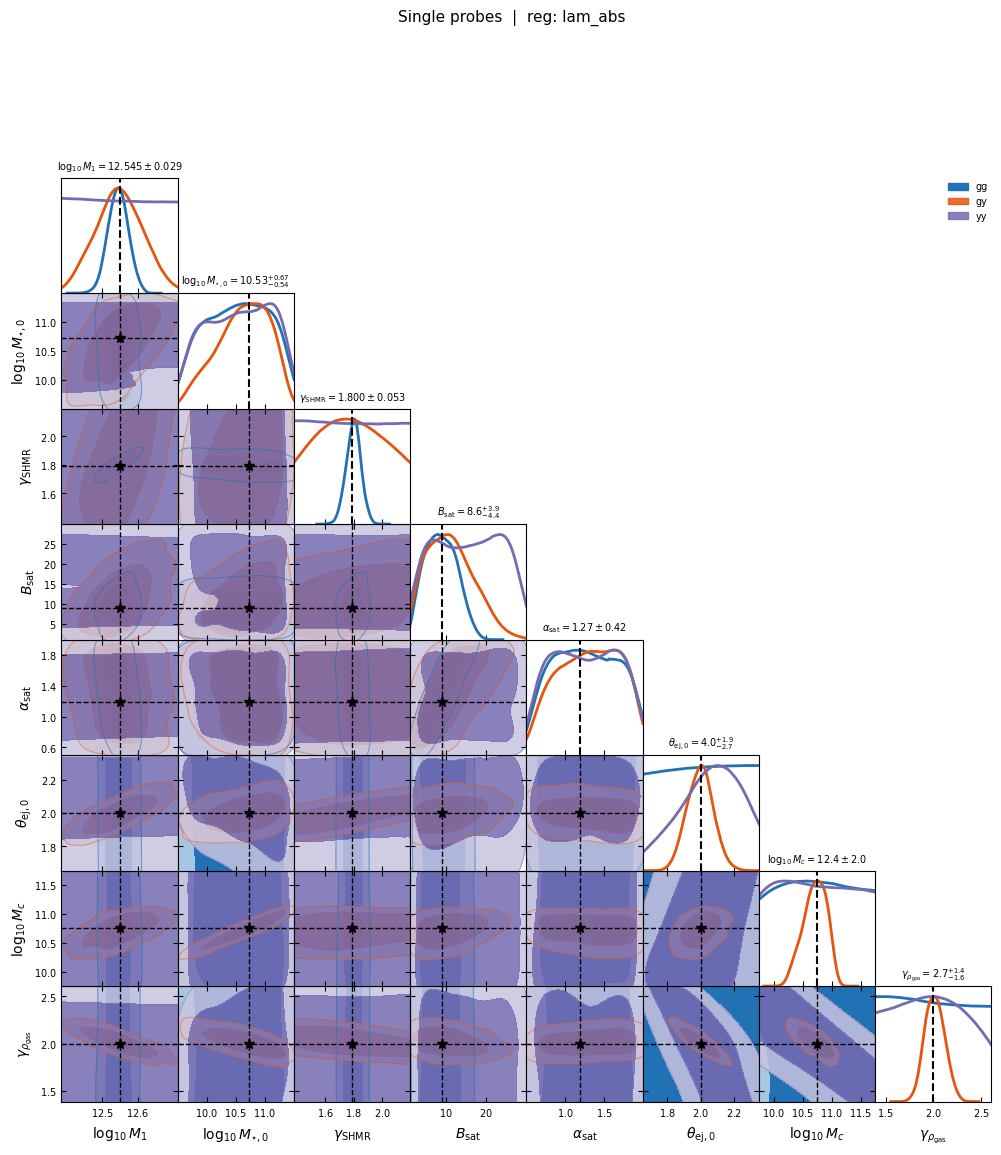

  saved -> /home/vtinnane/Documents/Codes/develop/GODMAX/notebooks/diagnostics/plots/inf_two_probe_combos.png


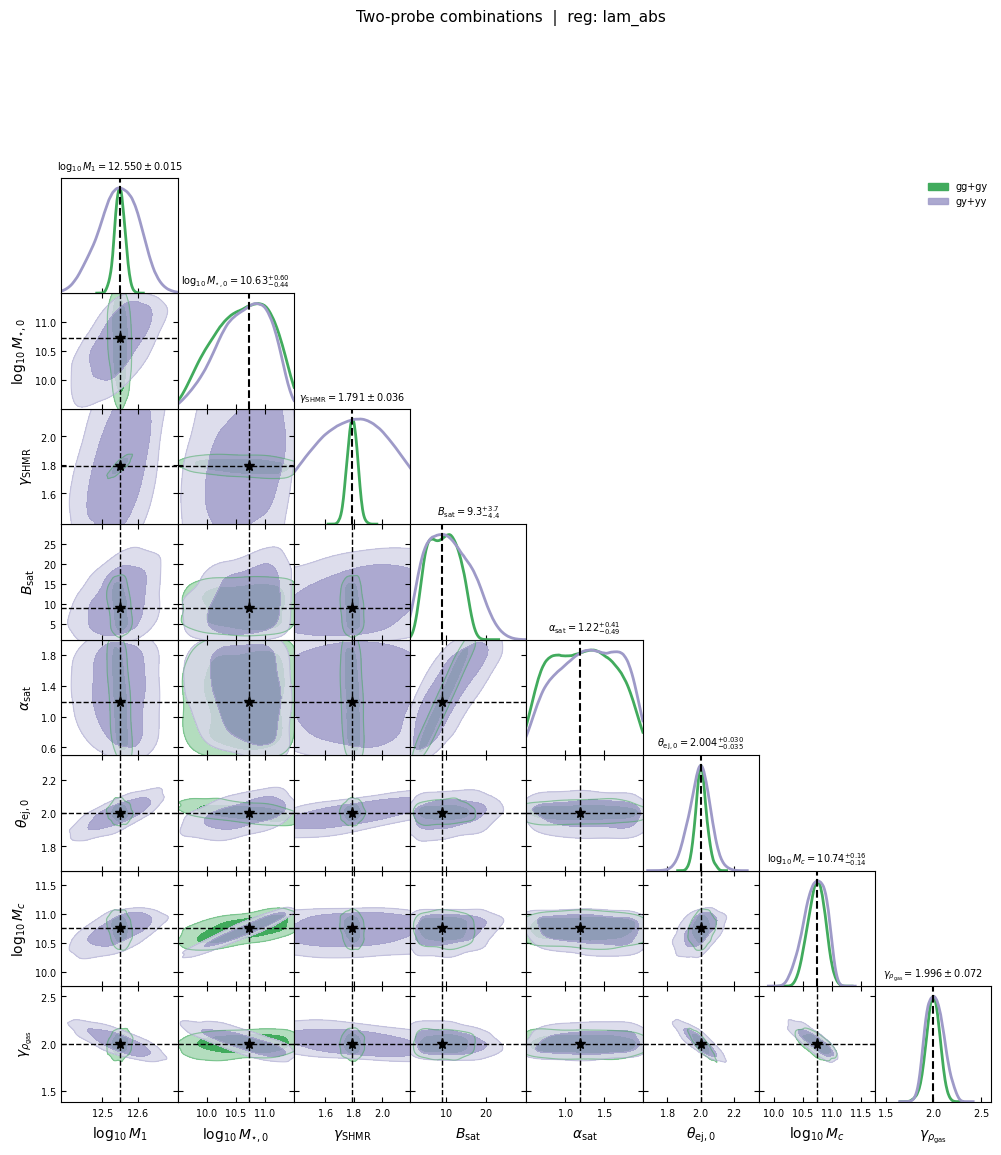

  saved -> /home/vtinnane/Documents/Codes/develop/GODMAX/notebooks/diagnostics/plots/inf_all.png


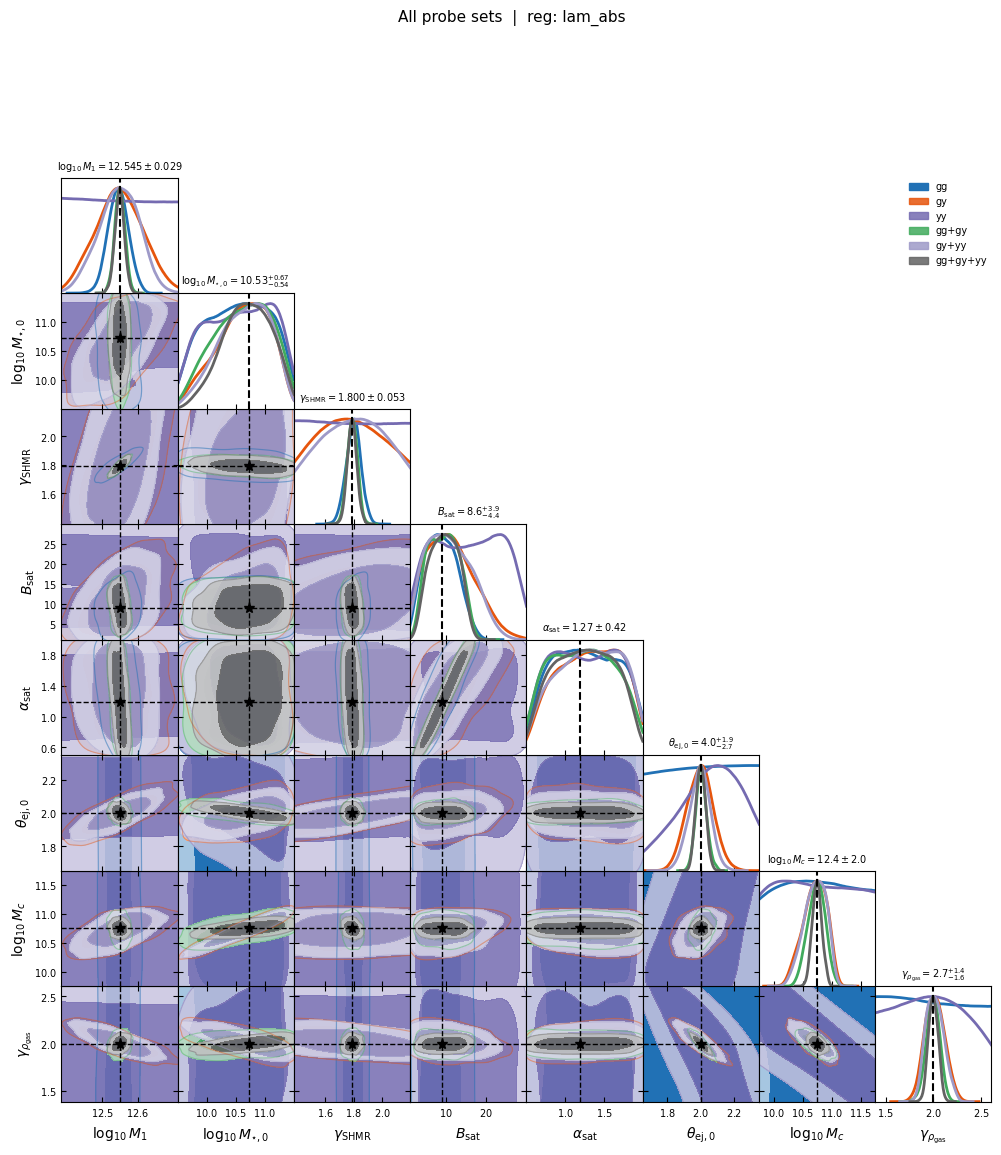

  saved -> /home/vtinnane/Documents/Codes/develop/GODMAX/notebooks/diagnostics/plots/gg_gy_gg+gy.png


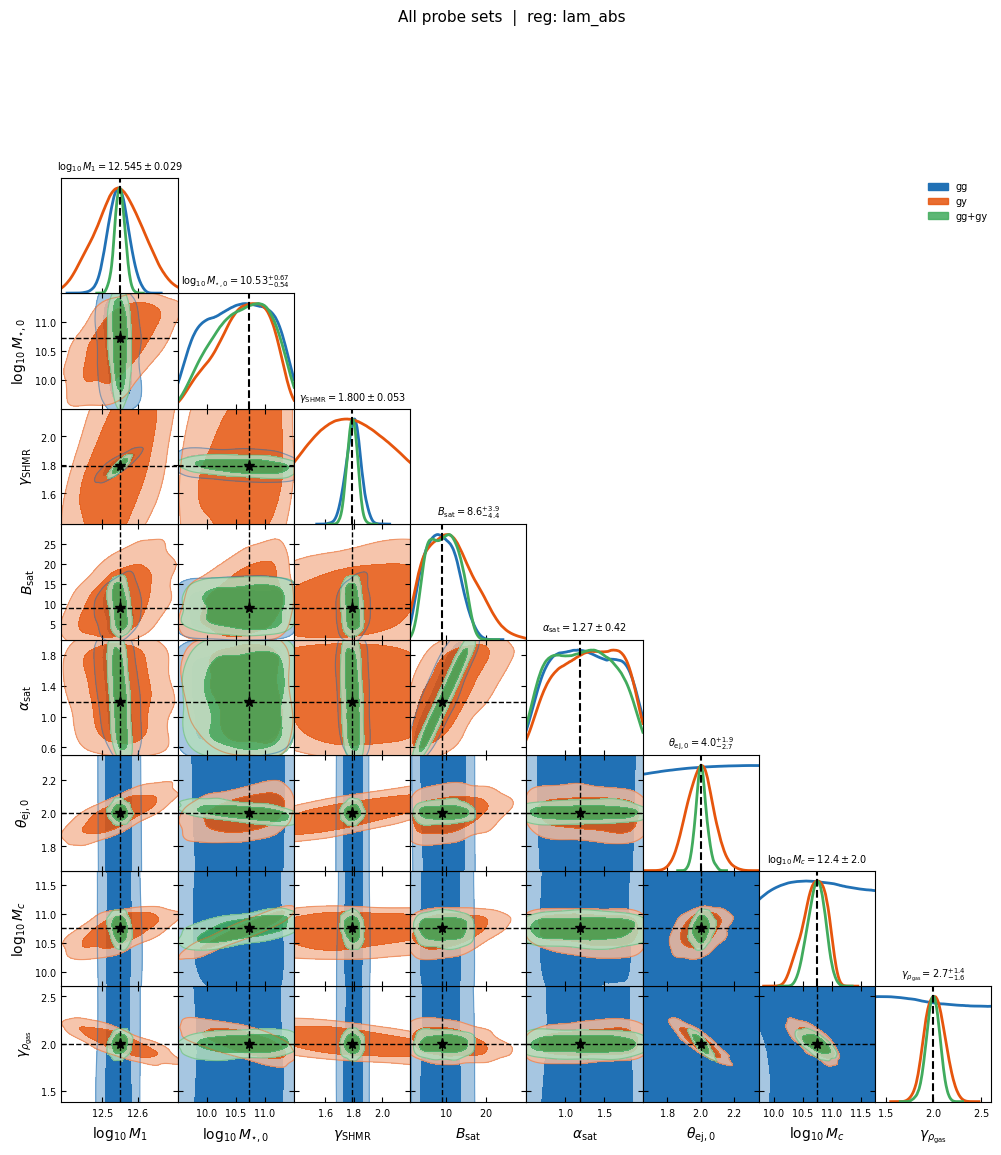

In [28]:
# ── Step 4: NUTS for every probe config ───────────────────────────────────
gd_samples = {}
for label, (probes, color) in PROBE_CONFIGS.items():
    print(f'\n=== {label} ===')
    gd_samples[label] = run_inference(
        probes_arr  = probes,
        cov_obj     = cov_test,
        jac_in      = J_all[label],
        entries_in  = entries_all[label],
        probe_label = label,
        probe_color = color,
        n_warmup    = 500,
        n_samples   = 2000,
    )

# ── Step 5: shared axis limits (from the most-constrained combined probe) ─
_ref = gd_samples['gg+gy+yy']
param_limits = {}
for p in param_names:
    _s = _ref.samples[:, param_names.index(p)]
    mu, sig = _s.mean(), _s.std()
    param_limits[p] = (max(prior_min[p], mu - 12*sig),
                       min(prior_max[p], mu + 12*sig))

# ── Step 6: plot_probes — call with any probe labels after this cell runs ─
def plot_probes(*probe_labels, fname=None, title=None, limits=None):
    """Triangle plot for any subset of probe labels defined in PROBE_CONFIGS.

    Examples
    --------
    plot_probes('gg', 'gy', 'yy')
    plot_probes('gg+gy', 'gg+gy+yy')
    plot_probes('gy', 'gy+yy', fname='custom.png')
    """
    missing = [l for l in probe_labels if l not in gd_samples]
    if missing:
        raise KeyError(f'Unknown probe labels: {missing}. '
                       f'Available: {list(gd_samples.keys())}')
    gd_list = [gd_samples[l] for l in probe_labels]
    colors  = [PROBE_CONFIGS[l][1] for l in probe_labels]
    if title is None:
        title = '  vs  '.join(probe_labels) + f'  |  reg: {REG_METHOD}'
    if fname is None:
        fname = 'inf_' + '_'.join(probe_labels).replace('+', '') + '.png'
    _triangle_plot(gd_list, colors, title, fname, limits or param_limits)

# ── Step 7: auto-generate standard plots ──────────────────────────────────
# individual probes
plot_probes('gg', 'gy', 'yy',
            fname='inf_single_probes.png',
            title='Single probes  |  reg: ' + REG_METHOD)
# two-probe combos
plot_probes('gg+gy', 'gy+yy',
            fname='inf_two_probe_combos.png',
            title='Two-probe combinations  |  reg: ' + REG_METHOD)
# all
plot_probes('gg', 'gy', 'yy', 'gg+gy', 'gy+yy', 'gg+gy+yy',
            fname='inf_all.png',
            title='All probe sets  |  reg: ' + REG_METHOD)
plot_probes('gg', 'gy', 'gg+gy',
            fname='gg_gy_gg+gy.png',
            title='All probe sets  |  reg: ' + REG_METHOD)

In [29]:
# =====================================================================
#  MULTI-REGULARISATION COMPARISON
#  Jacobians are reg-independent: reuses J_all / entries_all from above
#  Edit REG_METHODS_COMPARE, run the cell, then call plot_probes_reg()
# =====================================================================

# methods to compare — edit freely
REG_METHODS_COMPARE = ['lam_abs', 'diag_shift_x11']

# border linestyle per position in REG_METHODS_COMPARE
# first method: solid+filled; second: dashed+unfilled; third: dotted+unfilled ...
_REG_LS = ['-', '--', ':', '-.']   # cycles if > 4 methods

# ── run NUTS: one chain per (reg_method x probe_config) ──────────────────
gd_samples_reg = {}   # gd_samples_reg[reg][label] -> MCSamples

for reg in REG_METHODS_COMPARE:
    print('\n' + '='*50 + '  ' + reg + '  ' + '='*50)
    gd_samples_reg[reg] = {}
    for label, (probes, color) in PROBE_CONFIGS.items():
        print('\n--- ' + label + ' ---')
        gd_samples_reg[reg][label] = run_inference(
            probes_arr  = probes,
            cov_obj     = cov_test,
            jac_in      = J_all[label],
            entries_in  = entries_all[label],
            probe_label = label + ' (' + reg + ')',
            probe_color = color,
            reg_method  = reg,
            n_warmup    = 500,
            n_samples   = 2000,
        )


# ── plot_probes_reg ───────────────────────────────────────────────────────
# Visual convention:
#   colour   = probe  (same as plot_probes)
#   linestyle = reg method position: solid / dashed / dotted / dash-dot
#   fill      = only first reg method is filled; rest are outline-only

def plot_probes_reg(*probe_labels, reg_methods=None,
                    fname=None, title=None, limits=None):
    """Triangle plot comparing regularisation methods for given probes.

    Parameters
    ----------
    *probe_labels : str
        Any labels from PROBE_CONFIGS, e.g. 'gg', 'gy+yy'.
    reg_methods : list[str] | None
        Subset of REG_METHODS_COMPARE to plot (default: all run so far).

    Examples
    --------
    plot_probes_reg('gg', reg_methods=['lam_abs', 'diag_shift_x11'])
    plot_probes_reg('gg', 'gy', reg_methods=['lam_abs'])
    plot_probes_reg('gg', 'gy', 'yy', reg_methods=['lam_abs', 'diag_shift_x11'])
    """
    import os
    from getdist import plots as gd_plots
    import matplotlib.pyplot as pl

    if reg_methods is None:
        reg_methods = REG_METHODS_COMPARE

    bad_reg = [r for r in reg_methods if r not in gd_samples_reg]
    if bad_reg:
        raise KeyError('Reg methods not yet run: ' + str(bad_reg)
                       + '. Available: ' + str(list(gd_samples_reg.keys())))
    bad_probe = [l for l in probe_labels if l not in PROBE_CONFIGS]
    if bad_probe:
        raise KeyError('Unknown probe labels: ' + str(bad_probe)
                       + '. Available: ' + str(list(PROBE_CONFIGS.keys())))

    # build sample list: outer=probes, inner=reg methods
    gd_list    = []
    colors     = []
    filled     = []
    linestyles = []
    for probe in probe_labels:
        base_color = PROBE_CONFIGS[probe][1]
        for i_r, reg in enumerate(reg_methods):
            samp = gd_samples_reg[reg][probe]
            samp.label = probe + ' (' + reg + ')'
            gd_list.append(samp)
            colors.append(base_color)
            filled.append(i_r == 0)              # only first reg is filled
            linestyles.append(_REG_LS[i_r % len(_REG_LS)])

    if title is None:
        title = ('  vs  '.join(probe_labels)
                 + '  |  reg: ' + ', '.join(reg_methods))
    if fname is None:
        pstr  = '_'.join(p.replace('+', '') for p in probe_labels)
        rstr  = '_'.join(reg_methods)
        fname = 'inf_' + pstr + '_reg_' + rstr + '.png'

    fiducials = [float(theta_fid_dict[p]) for p in param_names]
    n_p = len(param_names)

    g = gd_plots.get_subplot_plotter(width_inch=12)
    g.settings.figure_legend_frame = False
    g.settings.legend_fontsize = 10
    g.triangle_plot(
        gd_list, param_names,
        filled         = filled,
        contour_colors = colors,
        contour_lws    = [2.0] * len(gd_list),
        contour_ls     = linestyles,
        title_limit    = 1,
        param_limits   = limits or param_limits,
        legend_loc     = 'upper right',
    )
    for row in range(n_p):
        for col in range(row + 1):
            ax = g.subplots[row, col]
            if ax is None:
                continue
            if row == col:
                ax.axvline(fiducials[col], color='k', ls='--', lw=1.5, zorder=5)
            else:
                ax.axvline(fiducials[col], color='k', ls='--', lw=1.0, zorder=5)
                ax.axhline(fiducials[row], color='k', ls='--', lw=1.0, zorder=5)
                ax.plot(fiducials[col], fiducials[row],
                        '*', color='k', ms=8, zorder=6)
    g.fig.suptitle(title, fontsize=11, y=1.02)
    os.makedirs(str(FIGDIR), exist_ok=True)
    g.fig.savefig(str(FIGDIR / fname), dpi=150, bbox_inches='tight')
    print('  saved -> ' + str(FIGDIR / fname))
    pl.show()



==================================================  lam_abs  ==================================================

--- gg ---
  [gg (lam_abs)]  n_dv=95  reg=lam_abs  lambda_min=1.73e-21  cond=3.01e+08
    log_p(theta_fid) = -11.8767  (log_like=0 + log_prior_norm=-11.8767)


sample: 100%|██████████| 2500/2500 [00:03<00:00, 657.33it/s, 15 steps of size 3.58e-01. acc. prob=0.84] 
arviz - WARNING - Shape validation failed: input_shape: (1, 2000), minimum_shape: (chains=2, draws=4)


    3.9s  |  R-hat max = nan
                     mean     sd  r_hat
log10M1_fshmr      12.545  0.029    NaN
log10Mstar0_fshmr  10.535  0.552    NaN
gamma_fshmr         1.800  0.053    NaN
Bsat_Nsat           8.624  3.941    NaN
alphasat_Nsat       1.272  0.424    NaN
theta_ej_0          4.015  2.103    NaN
log10_Mc0          12.431  2.020    NaN
gamma_rhogas        2.695  1.299    NaN
Removed no burn in

--- gy ---
  [gy (lam_abs)]  n_dv=95  reg=lam_abs  lambda_min=2.21e-32  cond=2.50e+08
    log_p(theta_fid) = -11.8767  (log_like=0 + log_prior_norm=-11.8767)


sample: 100%|██████████| 2500/2500 [00:03<00:00, 635.90it/s, 7 steps of size 3.10e-01. acc. prob=0.86]  
arviz - WARNING - Shape validation failed: input_shape: (1, 2000), minimum_shape: (chains=2, draws=4)


    4.1s  |  R-hat max = nan
                     mean     sd  r_hat
log10M1_fshmr      12.549  0.069    NaN
log10Mstar0_fshmr  10.631  0.454    NaN
gamma_fshmr         1.808  0.404    NaN
Bsat_Nsat          10.901  5.967    NaN
alphasat_Nsat       1.315  0.403    NaN
theta_ej_0          1.997  0.079    NaN
log10_Mc0          10.712  0.203    NaN
gamma_rhogas        2.014  0.105    NaN
Removed no burn in

--- yy ---
  [yy (lam_abs)]  n_dv=19  reg=lam_abs  lambda_min=9.67e-43  cond=7.97e+09
    log_p(theta_fid) = -11.8767  (log_like=0 + log_prior_norm=-11.8767)


...

    6.3s  |  R-hat max = nan
                     mean     sd  r_hat
log10M1_fshmr      12.549  0.029    NaN
log10Mstar0_fshmr  10.519  0.558    NaN
gamma_fshmr         1.794  0.053    NaN
Bsat_Nsat           9.436  3.909    NaN
alphasat_Nsat       1.255  0.415    NaN
theta_ej_0          1.890  0.907    NaN
log10_Mc0          12.274  1.951    NaN
gamma_rhogas        2.402  1.235    NaN
Removed no burn in

--- gy+yy ---
  [gy+yy (diag_shift_x11)]  n_dv=114  reg=diag_shift_x11  lambda_min=5.55e-34  cond=9.98e+09
    log_p(theta_fid) = -11.8767  (log_like=0 + log_prior_norm=-11.8767)


sample: 100%|██████████| 2500/2500 [00:03<00:00, 635.57it/s, 15 steps of size 2.88e-01. acc. prob=0.87] 
arviz - WARNING - Shape validation failed: input_shape: (1, 2000), minimum_shape: (chains=2, draws=4)


    4.1s  |  R-hat max = nan
                     mean     sd  r_hat
log10M1_fshmr      12.555  0.066    NaN
log10Mstar0_fshmr  10.697  0.434    NaN
gamma_fshmr         1.821  0.406    NaN
Bsat_Nsat          11.278  6.160    NaN
alphasat_Nsat       1.321  0.420    NaN
theta_ej_0          2.002  0.078    NaN
log10_Mc0          10.742  0.195    NaN
gamma_rhogas        2.002  0.101    NaN
Removed no burn in

--- gg+gy+yy ---
  [gg+gy+yy (diag_shift_x11)]  n_dv=209  reg=diag_shift_x11  lambda_min=5.22e-23  cond=1.00e+10
    log_p(theta_fid) = -11.8767  (log_like=0 + log_prior_norm=-11.8767)


sample: 100%|██████████| 2500/2500 [00:05<00:00, 499.83it/s, 15 steps of size 3.09e-01. acc. prob=0.91]
arviz - WARNING - Shape validation failed: input_shape: (1, 2000), minimum_shape: (chains=2, draws=4)


    5.2s  |  R-hat max = nan
                     mean     sd  r_hat
log10M1_fshmr      12.551  0.028    NaN
log10Mstar0_fshmr  10.485  0.559    NaN
gamma_fshmr         1.798  0.053    NaN
Bsat_Nsat           9.442  3.936    NaN
alphasat_Nsat       1.244  0.422    NaN
theta_ej_0          1.872  0.886    NaN
log10_Mc0          12.302  1.938    NaN
gamma_rhogas        2.398  1.273    NaN
Removed no burn in


  saved -> /home/vtinnane/Documents/Codes/develop/GODMAX/notebooks/diagnostics/plots/inf_gg_gy_gggy_reg_lam_abs_diag_shift_x11.png


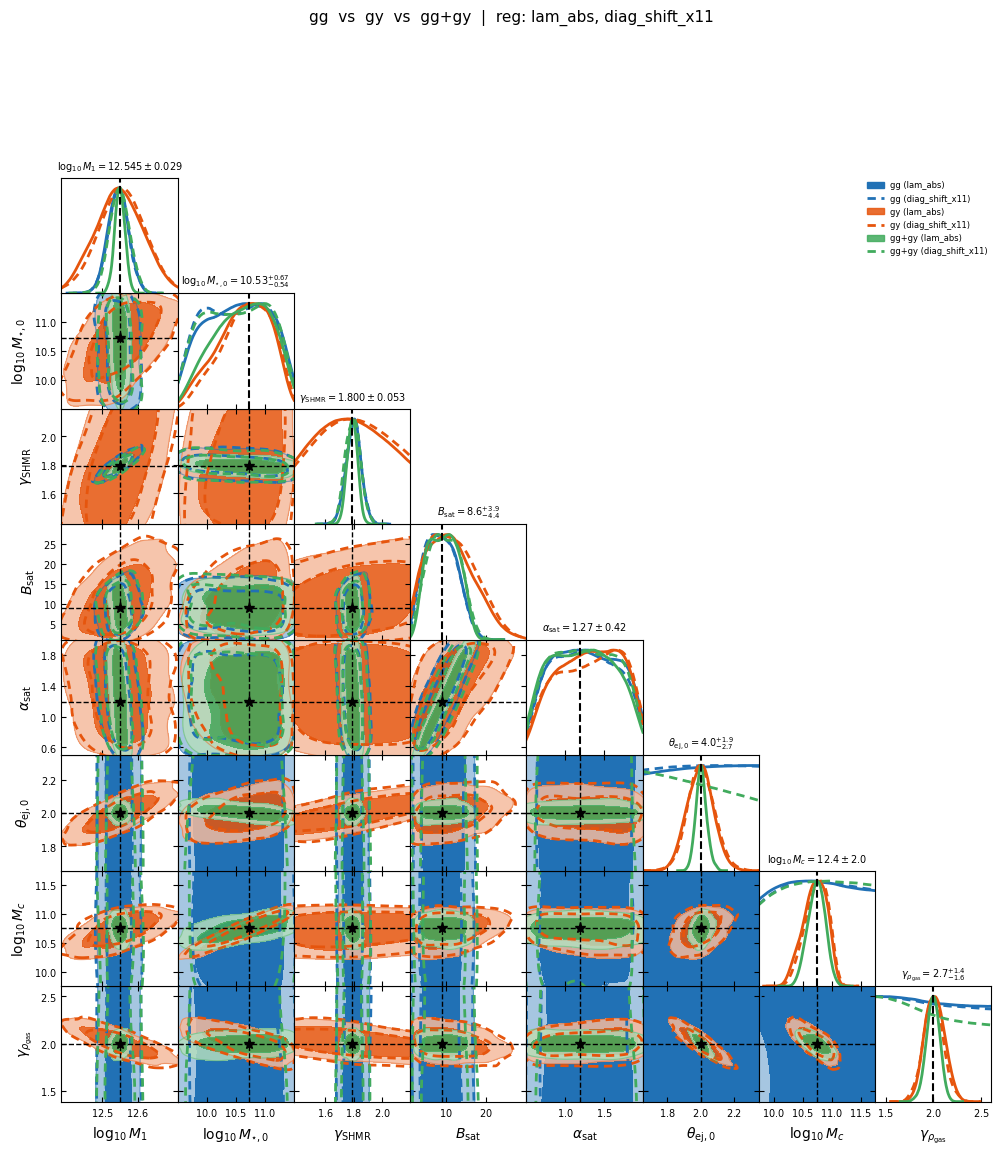

In [30]:
plot_probes_reg('gg', 'gy', 'gg+gy', reg_methods=None,
                    fname=None, title=None, limits=None)



---
## Regularisation methods formulae

All methods start from the eigendecomposition
$$C = Q\,\Lambda\,Q^\top, \qquad \Lambda = \mathrm{diag}(\lambda_1,\dots,\lambda_n), \quad \lambda_1 \le \cdots \le \lambda_n$$
and return $C_\mathrm{reg} = Q\,\mathrm{diag}(\lambda^\mathrm{new})\,Q^\top$ unless noted otherwise.

---

### Eigenvalue clipping / shifting

| Method | Formula | Notes |
|--------|---------|-------|
| **clip** $\lambda<0$ | $\lambda^\mathrm{new}_i = max(\lambda_i,\;\varepsilon_\mathrm{mach}\,\lambda_n)$ | Floor at machine-epsilon times $\lambda_max$ to avoid reconstruction roundoff |
| **diag shift** | $C_\mathrm{reg} = C + \delta\,I,\quad \delta = max(0,-\lambda_1)$ | Adds the absolute value of the most-negative eigenvalue uniformly to the diagonal |
| **diag shift** $\times 1.1$ | $C_\mathrm{reg} = C + (1.1\,|\lambda_1| + \varepsilon)\,I$ | Extra 10% margin plus small $\varepsilon=10^{-10}\lambda_n$ to ensure strict positivity |
| **$\lvert\lambda\rvert$ reflection** | $\lambda^\mathrm{new}_i = \lvert\lambda_i\rvert$ | Reflects negative eigenvalues through zero; equivalent to the congruence transform $D\,C\,D$ with $D = \mathrm{diag}(\mathrm{sign}(\lambda_i))$ |

### Noise floor

| Method | Formula | Notes |
|--------|---------|-------|
| **noise floor** $\alpha$ | $\lambda^\mathrm{new}_i = \lambda_i + \alpha\,\bar{C}_{ii}$ | Adds a fraction $\alpha$ of the mean diagonal to every eigenvalue; $\alpha=10^{-3}$ or $10^{-2}$ |

### Condition-number regularisation (CNR) (https://pmc.ncbi.nlm.nih.gov/articles/PMC3667751/)

$$\tau = \frac{\lambda_n}{\kappa_max}, \qquad \lambda^\mathrm{new}_i = max(\lambda_i,\,\tau)$$

Clamps the condition number to $\kappa_max$: any eigenvalue smaller than $\lambda_n/\kappa_max$ is raised to that floor.

### Mode truncation

Sort eigenvalues ascending. Set the $N_\mathrm{trunc}$ smallest to the value of the $(N_\mathrm{trunc}+1)$-th eigenvalue:
$$\lambda^\mathrm{new}_i = \begin{cases} \lambda_{N_\mathrm{trunc}+1} & i \le N_\mathrm{trunc} \\ \lambda_i & i > N_\mathrm{trunc} \end{cases}$$

### Hard thresholding on the correlation matrix: ([Bickel & Levina (2008)](https://www.stat.berkeley.edu/~bickel/BL2008Aos-thresholding.pdf))

Convert $C$ to the correlation matrix $\rho$, threshold small off-diagonal entries, then convert back:
$$\rho_{ij} = \frac{C_{ij}}{\sqrt{C_{ii}\,C_{jj}}}, \qquad
\rho^\mathrm{thresh}_{ij} = \begin{cases} \rho_{ij} & |\rho_{ij}| \ge s \\ 0 & |\rho_{ij}| < s \end{cases} \quad (i\ne j)$$
with $s = f\cdot\max_{i\ne j}|\rho_{ij}|$, $f\in\{0.01,0.05\}$. Then $C_\mathrm{reg} = D\,\rho^\mathrm{thresh}\,D$ where $D=\mathrm{diag}(\sqrt{C_{ii}})$.

### Eigenvalue perturbation

$$\lambda^\mathrm{new}_i = |\lambda_i|\,(1+\delta_i), \qquad \delta_i \sim \mathcal{N}\!\left(0,\,\frac{x}{100}\right), \quad |\delta_i| < 1$$

Taking $|\lambda_i|$ first ensures all new eigenvalues are strictly positive; $x$ (in percent) controls the perturbation magnitude.

---

## Regularisation selection criteria

Methods that fail **C1** (not PSD after regularisation) are excluded from the ranking.
The remaining methods are ranked on each criterion independently (rank 1 = best).
The **best method** minimises the sum of ranks.

| Criterion | Symbol | Definition | Target |
|-----------|--------|------------|--------|
| **C1** PSD | — | $\lambda_min > 0$ | necessary condition |
| **C2** Condition number | $\kappa$ | $\kappa = \lambda_max / \lambda_min$ | lower $\Rightarrow$ more numerically stable |
| **C3** Frobenius fidelity | $\Delta_F$ | $\|C_\mathrm{reg} - C\|_F \;/\; \|C\|_F$ | lower $\Rightarrow$ less total distortion |
| **C4** Diagonal fidelity | $\Delta_\mathrm{diag}$ | $\max_i \left\lvert C_\mathrm{reg,ii}/C_{ii} - 1\right\rvert$ | lower $\Rightarrow$ variances preserved |
| **C5** Mock $\chi^2$ | $\chi^2/n$ | mean $\chi^2$ over 200 mock realisations drawn from $C$, evaluated with $C_\mathrm{reg}^{-1}$, divided by $n_\mathrm{dv}$ | $\approx 1$ |
| **C6** Correlation fidelity | $\Delta_\rho$ | $\displaystyle\frac{1}{n(n-1)}\sum_{i\ne j}\left\lvert\rho_\mathrm{reg,ij} - \rho_{ij}\right\rvert$ | lower $\Rightarrow$ correlation structure preserved |

where $\rho_{ij} = C_{ij}/\sqrt{C_{ii}\,C_{jj}}$ is the Pearson correlation coefficient of the covariance matrix.
